In [3]:
import pandas as pd
import numpy as np
pd.set_option('future.no_silent_downcasting', True)
df = pd.read_csv('railway.csv')
print(df.shape)
display(df.head())

(31653, 18)


,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


In [5]:
df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))
column_mapping = {
    'Transaction ID': 'transaction_id',
    'Date of Purchase': 'date_of_purchase',
    'Time of Purchase': 'time_of_purchase',
    'Purchase Type': 'purchase_type',
    'Payment Method': 'payment_method',
    'Railcard': 'railcard',
    'Ticket Class': 'ticket_class',
    'Ticket Type': 'ticket_type',
    'Price': 'price',
    'Departure Station': 'departure_station',
    'Arrival Destination': 'arrival_destination',
    'Date of Journey': 'date_of_journey',
    'Departure Time': 'departure_time',
    'Arrival Time': 'arrival_time',
    'Actual Arrival Time': 'actual_arrival_time',
    'Journey Status': 'journey_status',
    'Reason for Delay': 'reason_for_delay',
    'Refund Request': 'refund_request'
}

df.rename(columns=column_mapping, inplace=True)
print(df.columns)
display(df.head())

Index(['transaction_id', 'date_of_purchase', 'time_of_purchase',
       'purchase_type', 'payment_method', 'railcard', 'ticket_class',
       'ticket_type', 'price', 'departure_station', 'arrival_destination',
       'date_of_journey', 'departure_time', 'arrival_time',
       'actual_arrival_time', 'journey_status', 'reason_for_delay',
       'refund_request'],
      dtype='object')


,transaction_id,date_of_purchase,time_of_purchase,purchase_type,payment_method,railcard,ticket_class,ticket_type,price,departure_station,arrival_destination,date_of_journey,departure_time,arrival_time,actual_arrival_time,journey_status,reason_for_delay,refund_request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


In [7]:
df['railcard'] = df['railcard'].replace({'None': 'No Railcard', 'nan': 'No Railcard', '': 'No Railcard'})
df['ticket_type'] = df['ticket_type'].replace({'Advance': 'Pre-Booked', 'Anytime': 'Instant-Booked'})

delay_reason_fix = {
    'Staffing': 'Staff Shortage',
    'Weather Conditions': 'Weather',
    'Signal failure': 'Signal Failure',
    'nan': 'No Delay'
}
df['reason_for_delay'] = df['reason_for_delay'].replace(delay_reason_fix)


df.loc[df['journey_status'] == 'On Time', 'reason_for_delay'] = df.loc[df['journey_status'] == 'On Time', 'reason_for_delay'].fillna('No Delay')


df['reason_for_delay'] = df['reason_for_delay'].fillna('Unknown')


display(df[['journey_status', 'reason_for_delay']].drop_duplicates())

,journey_status,reason_for_delay
0,On Time,No Delay
1,Delayed,Signal Failure
20,Delayed,Technical Issue
39,Cancelled,Technical Issue
45,Delayed,Weather
111,Cancelled,Staff Shortage
154,Cancelled,Signal Failure
227,Delayed,Staff Shortage
272,Cancelled,Weather
654,Cancelled,Traffic


In [9]:
df['date_of_purchase'] = pd.to_datetime(df['date_of_purchase'], errors='coerce')
df['date_of_journey'] = pd.to_datetime(df['date_of_journey'], errors='coerce')

df['departure_time'] = pd.to_timedelta(df['departure_time'], errors='coerce')
df['arrival_time'] = pd.to_timedelta(df['arrival_time'], errors='coerce')
df['actual_arrival_time'] = pd.to_timedelta(df['actual_arrival_time'].fillna('00:00:00'), errors='coerce')

df = df[df['price'] >= 0]
df = df[df['date_of_journey'] >= df['date_of_purchase']]
df.info()
display(df[['departure_time','arrival_time','actual_arrival_time']].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype          
---  ------               --------------  -----          
 0   transaction_id       31653 non-null  object         
 1   date_of_purchase     31653 non-null  datetime64[ns] 
 2   time_of_purchase     31653 non-null  object         
 3   purchase_type        31653 non-null  object         
 4   payment_method       31653 non-null  object         
 5   railcard             10735 non-null  object         
 6   ticket_class         31653 non-null  object         
 7   ticket_type          31653 non-null  object         
 8   price                31653 non-null  int64          
 9   departure_station    31653 non-null  object         
 10  arrival_destination  31653 non-null  object         
 11  date_of_journey      31653 non-null  datetime64[ns] 
 12  departure_time       31653 non-null  timedelta64[ns]
 13  arrival_time    

,departure_time,arrival_time,actual_arrival_time
0,0 days 11:00:00,0 days 13:30:00,0 days 13:30:00
1,0 days 09:45:00,0 days 11:35:00,0 days 11:40:00
2,0 days 18:15:00,0 days 18:45:00,0 days 18:45:00
3,0 days 21:30:00,0 days 22:30:00,0 days 22:30:00
4,0 days 16:45:00,0 days 19:00:00,0 days 19:00:00


In [11]:
mask_on_time = (df['actual_arrival_time'] <= df['arrival_time']) & (df['journey_status'] != 'Cancelled')

df.loc[mask_on_time, 'journey_status'] = 'On Time'
df.loc[df['journey_status'] == 'On Time', 'reason_for_delay'] = 'No Delay'
df.loc[df['journey_status'] == 'On Time', 'refund_request'] = 'No'
df['journey_status'].value_counts()

journey_status
On Time      27499
Delayed       2274
Cancelled     1880
Name: count, dtype: int64

In [13]:
df['departure_station'] = df['departure_station'].replace({'Edinburgh': 'Edinburgh Waverley'})
df['arrival_destination'] = df['arrival_destination'].replace({'Edinburgh': 'Edinburgh Waverley'})
df['route_name'] = df['departure_station'] + ' to ' + df['arrival_destination']

In [15]:
df['route_name'] = df['departure_station'] + ' to ' + df['arrival_destination']

def get_time_of_day(td):
    if pd.isna(td): return 'Night'
    h = td.components.hours
    if 6 <= h <= 11: return 'Morning'
    elif 12 <= h <= 16: return 'Afternoon'
    elif 17 <= h <= 21: return 'Evening'
    else: return 'Night'

df['time_of_day'] = df['departure_time'].apply(get_time_of_day)

df['is_weekend'] = df['date_of_journey'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)
df['day_type'] = df['is_weekend'].map({1: 'Weekend', 0: 'Weekday'})
display(df[['route_name','time_of_day','day_type']].head())

,route_name,time_of_day,day_type
0,London Paddington to Liverpool Lime Street,Morning,Weekday
1,London Kings Cross to York,Morning,Weekday
2,Liverpool Lime Street to Manchester Piccadilly,Evening,Weekday
3,London Paddington to Reading,Evening,Weekday
4,Liverpool Lime Street to London Euston,Afternoon,Weekday


In [17]:
check_unique = df[df['departure_station'].str.contains('Edin', na=False)]['departure_station'].unique()
print("Names of Edinburgh's existing stations:")
print(check_unique)

Names of Edinburgh's existing stations:
['Edinburgh Waverley']


In [19]:
df['delay_minutes'] = (df['actual_arrival_time'] - df['arrival_time']).dt.total_seconds() / 60
df['delay_minutes'] = df['delay_minutes'].clip(lower=0).fillna(0)
df.loc[df['journey_status'] != 'Delayed', 'delay_minutes'] = 0

def delay_severity(row):
    d = row['delay_minutes']
    if row['journey_status'] != 'Delayed': return 'On Schedule'
    if d <= 15: return 'Almost On Time'
    if d <= 30: return 'Delayed'
    if d <= 60: return 'Heavily Delayed'
    return 'Critical Delay'

df['delay_severity'] = df.apply(delay_severity, axis=1)
display(df[['delay_minutes','delay_severity']].head())

,delay_minutes,delay_severity
0,0.0,On Schedule
1,5.0,Almost On Time
2,0.0,On Schedule
3,0.0,On Schedule
4,0.0,On Schedule


In [20]:
def get_peak_hour_flag(row):
    if pd.isna(row['departure_time']) or pd.isna(row['date_of_journey']):
        return 'Off-Peak'
    
    if row['date_of_journey'].weekday() < 5:
        hour = row['departure_time'].components.hours
        if (6 <= hour <= 8) or (16 <= hour <= 18):
            return 'Peak'
    return 'Off-Peak'

df['peak_hour_flag'] = df.apply(get_peak_hour_flag, axis=1)

df['revenue_at_risk'] = np.where(df['refund_request'] == 'Yes', df['price'], 0)

def revenue_tier(p):
    if p < 20: return 'Budget'
    elif p < 50: return 'Standard'
    elif p < 100: return 'Premium'
    else: return 'Luxury'

df['revenue_tier'] = df['price'].apply(revenue_tier)
display(df[['revenue_at_risk','revenue_tier','revenue_at_risk','peak_hour_flag']].head())
display(df['revenue_tier'].value_counts())

,revenue_at_risk,revenue_tier,revenue_at_risk,peak_hour_flag
0,0,Standard,0,Off-Peak
1,0,Standard,0,Off-Peak
2,0,Budget,0,Peak
3,0,Budget,0,Off-Peak
4,0,Premium,0,Peak


revenue_tier
Budget      21669
Standard     4922
Premium      3924
Luxury       1138
Name: count, dtype: int64

In [22]:
def get_comp_factor(delay):
    if delay >= 60: return 1.0
    elif delay >= 30: return 0.5
    elif delay >= 15: return 0.25
    else: return 0.0

df['compensation_factor'] = df['delay_minutes'].apply(get_comp_factor)
df['net_revenue'] = df['price'] * (1 - df['compensation_factor'])

def performance(row):
    if row['journey_status'] == 'Cancelled' or row['delay_minutes'] > 30:
        return 'Poor'
    elif row['journey_status'] == 'Delayed':
        return 'Average'
    return 'Good'

df['journey_performance'] = df.apply(performance, axis=1)
display(df[['journey_performance','compensation_factor','net_revenue','journey_status', 'delay_minutes', 'price']].head())

,journey_performance,compensation_factor,net_revenue,journey_status,delay_minutes,price
0,Good,0.0,43.0,On Time,0.0,43
1,Average,0.0,23.0,Delayed,5.0,23
2,Good,0.0,3.0,On Time,0.0,3
3,Good,0.0,13.0,On Time,0.0,13
4,Good,0.0,76.0,On Time,0.0,76


In [23]:
df['is_on_time_flag'] = (df['journey_status'] == 'On Time').astype(int)
df['is_delayed_flag'] = (df['journey_status'] == 'Delayed').astype(int)
df['is_cancelled_flag'] = (df['journey_status'] == 'Cancelled').astype(int)
display(df[['date_of_purchase','date_of_journey',
            'journey_status','is_on_time_flag','is_delayed_flag','is_cancelled_flag']].head())
print(df[['is_on_time_flag','is_delayed_flag','is_cancelled_flag']].sum())

,date_of_purchase,date_of_journey,journey_status,is_on_time_flag,is_delayed_flag,is_cancelled_flag
0,2023-12-08,2024-01-01,On Time,1,0,0
1,2023-12-16,2024-01-01,Delayed,0,1,0
2,2023-12-19,2024-01-02,On Time,1,0,0
3,2023-12-20,2024-01-01,On Time,1,0,0
4,2023-12-27,2024-01-01,On Time,1,0,0


is_on_time_flag      27499
is_delayed_flag       2274
is_cancelled_flag     1880
dtype: int64


In [28]:
dim_date = df[['date_of_journey', 'is_weekend', 'day_type']].drop_duplicates().reset_index(drop=True)
dim_date['date_key'] = dim_date.index + 1
dim_date['day_name'] = dim_date['date_of_journey'].dt.day_name()
dim_date['month_name'] = dim_date['date_of_journey'].dt.month_name()
dim_date['year'] = dim_date['date_of_journey'].dt.year

dim_route = df[['departure_station', 'arrival_destination', 'route_name']].drop_duplicates().reset_index(drop=True)
dim_route['route_key'] = dim_route.index + 1

dim_journey = df[['journey_status', 'reason_for_delay', 'delay_severity', 'journey_performance']].drop_duplicates().reset_index(drop=True)
dim_journey['journey_key'] = dim_journey.index + 1

dim_ticket = df[['ticket_class', 'ticket_type', 'railcard', 'revenue_tier']].drop_duplicates().reset_index(drop=True)
dim_ticket['ticket_key'] = dim_ticket.index + 1

In [30]:
print(f"--- Dim_Date: {len(dim_date)} ---")
display(dim_date.head(3))

print(f"\n--- Dim_Route: {len(dim_route)}   ---")
display(dim_route.head(3))

print(f"\n--- Dim_Journey: {len(dim_journey)}  ---")
display(dim_journey.head(3))

print(f"\n--- Dim_Ticket: {len(dim_ticket)}    ---")
display(dim_ticket.head(3))

--- Dim_Date: 121 ---


,date_of_journey,is_weekend,day_type,date_key,day_name,month_name,year
0,2024-01-01,0,Weekday,1,Monday,January,2024
1,2024-01-02,0,Weekday,2,Tuesday,January,2024
2,2024-01-03,0,Weekday,3,Wednesday,January,2024



--- Dim_Route: 64   ---


,departure_station,arrival_destination,route_name,route_key
0,London Paddington,Liverpool Lime Street,London Paddington to Liverpool Lime Street,1
1,London Kings Cross,York,London Kings Cross to York,2
2,Liverpool Lime Street,Manchester Piccadilly,Liverpool Lime Street to Manchester Piccadilly,3



--- Dim_Journey: 26  ---


,journey_status,reason_for_delay,delay_severity,journey_performance,journey_key
0,On Time,No Delay,On Schedule,Good,1
1,Delayed,Signal Failure,Almost On Time,Average,2
2,Delayed,Signal Failure,Delayed,Average,3



--- Dim_Ticket: 82    ---


,ticket_class,ticket_type,railcard,revenue_tier,ticket_key
0,Standard,Pre-Booked,Adult,Standard,1
1,Standard,Pre-Booked,NaN,Budget,2
2,Standard,Pre-Booked,NaN,Premium,3


In [32]:
fact = df.merge(dim_route, on=['departure_station','arrival_destination','route_name']) \
         .merge(dim_journey, on=['journey_status','reason_for_delay','delay_severity','journey_performance']) \
         .merge(dim_ticket, on=['ticket_class','ticket_type','railcard','revenue_tier']) \
         .merge(dim_date, on='date_of_journey')

fact = fact[[
    'transaction_id','date_key','route_key','journey_key','ticket_key',
    'price','net_revenue','revenue_at_risk','delay_minutes',
    'lead_time_days','compensation_factor','time_of_day','peak_hour_flag',
    'is_on_time_flag','is_delayed_flag','is_cancelled_flag'
]]

KeyError: "['lead_time_days'] not in index"

In [ ]:
display(fact.sample(10).reset_index(drop=True))


In [ ]:
def check_off_peak_rule_final(row):
    hour = row['departure_time'].components.hours
    is_peak_time = (6 <= hour <= 8) or (16 <= hour <= 18)
    
   
    is_weekday = row['date_of_journey'].weekday() < 5
    
    
    if row['ticket_type'] == 'Off-Peak' and is_peak_time and is_weekday:
        return 'Violation'
    else:
        return 'Compliant'

df['off_peak_compliance'] = df.apply(check_off_peak_rule_final, axis=1)
print(df['off_peak_compliance'].value_counts())

In [38]:
# ==========================================
# OVERVIEW: The Big Numbers
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# إعدادات الوضوح العام للرسومات
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# حساب الأرقام
total_journeys = len(df)
total_routes = df['route_name'].nunique()
total_stations = df['departure_station'].nunique()

print(f"--- الملخص العام ---")
print(f"إجمالي عدد الرحلات: {total_journeys:,}")
print(f"إجمالي عدد المسارات (Lines): {total_routes}")
print(f"إجمالي عدد المحطات: {total_stations}")

--- الملخص العام ---
إجمالي عدد الرحلات: 31,653
إجمالي عدد المسارات (Lines): 64
إجمالي عدد المحطات: 12


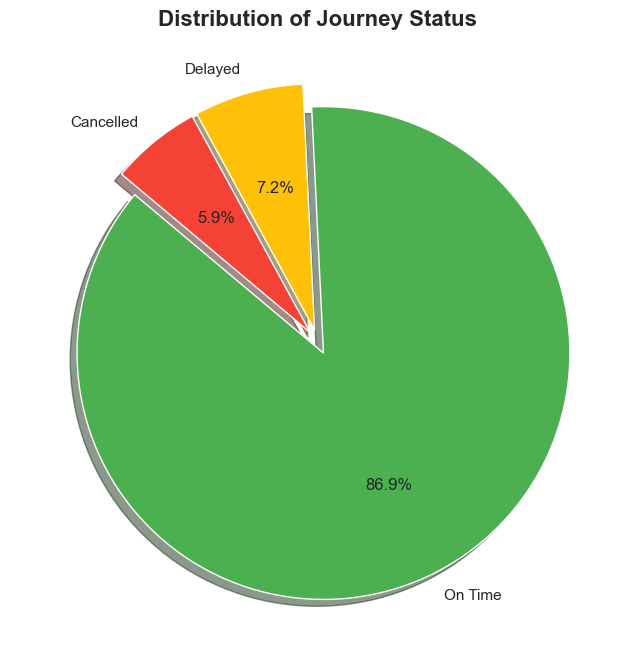

In [40]:
# ==========================================
# Q1: Journey Status Percentages
# ==========================================

status_counts = df['journey_status'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=['#4CAF50', '#FFC107', '#F44336'], 
        explode=(0.05, 0.05, 0.05), shadow=True)

plt.title('Distribution of Journey Status', fontsize=16, fontweight='bold')
plt.show()

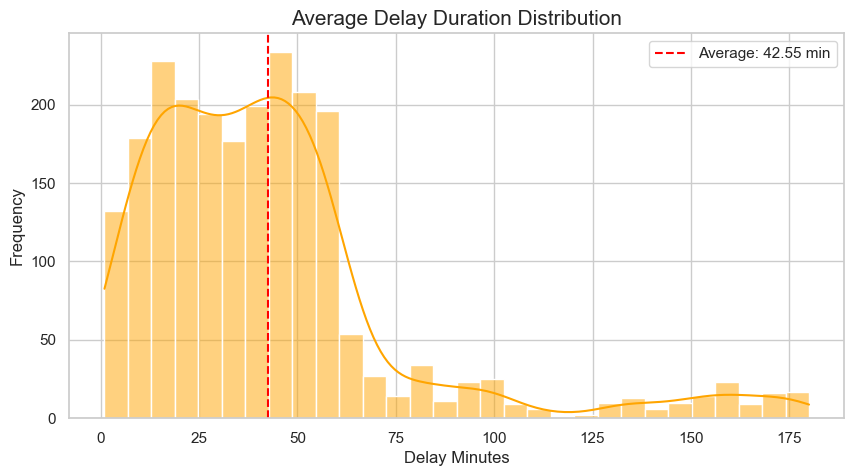

In [42]:
# ==========================================
# Q2: Average Delay Duration
# ==========================================

# بنحسب المتوسط للقطارات اللي اتأخرت فعلاً (عشان الرقم يكون له معنى)
avg_delay = df[df['journey_status'] == 'Delayed']['delay_minutes'].mean()

plt.figure(figsize=(10, 5))
sns.histplot(df[df['delay_minutes'] > 0]['delay_minutes'], bins=30, kde=True, color='orange')

plt.axvline(avg_delay, color='red', linestyle='--', label=f'Average: {avg_delay:.2f} min')
plt.title('Average Delay Duration Distribution', fontsize=15)
plt.xlabel('Delay Minutes')
plt.ylabel('Frequency')
plt.legend()
plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\2761799630.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_problematic_stations['disruption_rate'], y=top_problematic_stations.index, palette='Reds_r')


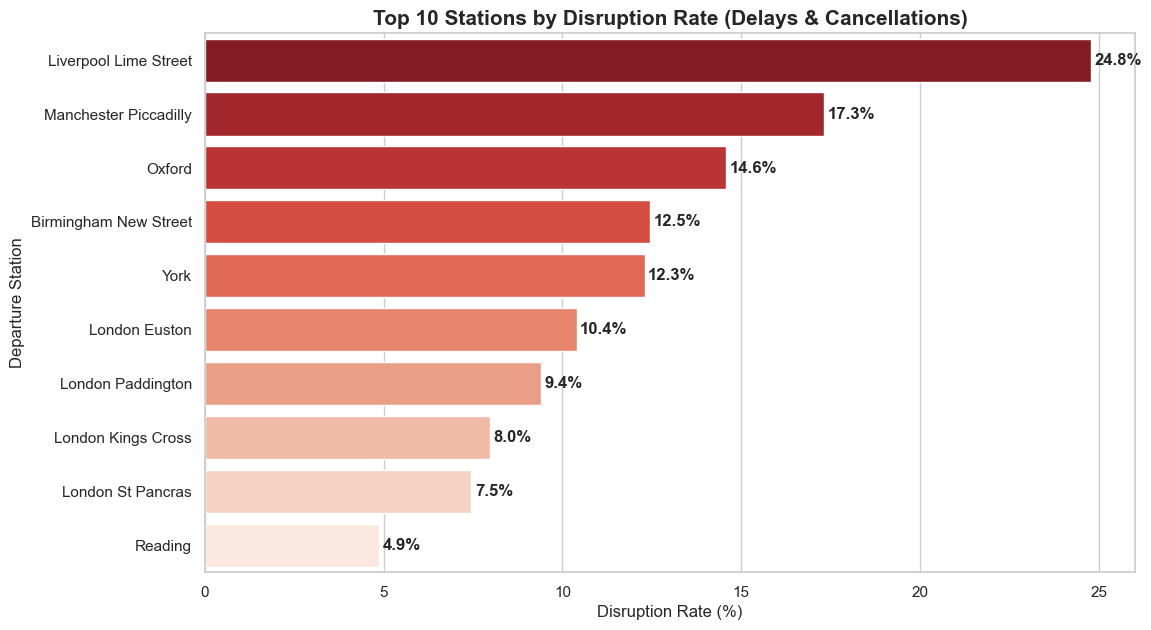

In [44]:
# ==========================================
# Q3: Most Disrupted Stations (Rate Based)
# ==========================================

# 1. حساب إجمالي الرحلات والرحلات المتعطلة لكل محطة
station_perf = df.groupby('departure_station').agg(
    total_trips=('transaction_id', 'count'),
    disrupted_trips=('journey_status', lambda x: x.isin(['Delayed', 'Cancelled']).sum())
)

# 2. حساب النسبة (معدل التعطل)
station_perf['disruption_rate'] = (station_perf['disrupted_trips'] / station_perf['total_trips']) * 100

# 3. اختيار أعلى 10 محطات (بشرط يكون طلع منها عدد رحلات معقول)
top_problematic_stations = station_perf[station_perf['total_trips'] > 100].nlargest(10, 'disruption_rate')

# 4. الرسم البياني (Bar Chart)
plt.figure(figsize=(12, 7))
sns.barplot(x=top_problematic_stations['disruption_rate'], y=top_problematic_stations.index, palette='Reds_r')

plt.title('Top 10 Stations by Disruption Rate (Delays & Cancellations)', fontsize=15, fontweight='bold')
plt.xlabel('Disruption Rate (%)')
plt.ylabel('Departure Station')

# إضافة الأرقام على الأعمدة
for index, value in enumerate(top_problematic_stations['disruption_rate']):
    plt.text(value + 0.1, index, f'{value:.1f}%', va='center', fontweight='bold')

plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\2246396454.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_delay_comp, x='after_4pm_flag', y='delay_minutes', palette='coolwarm')


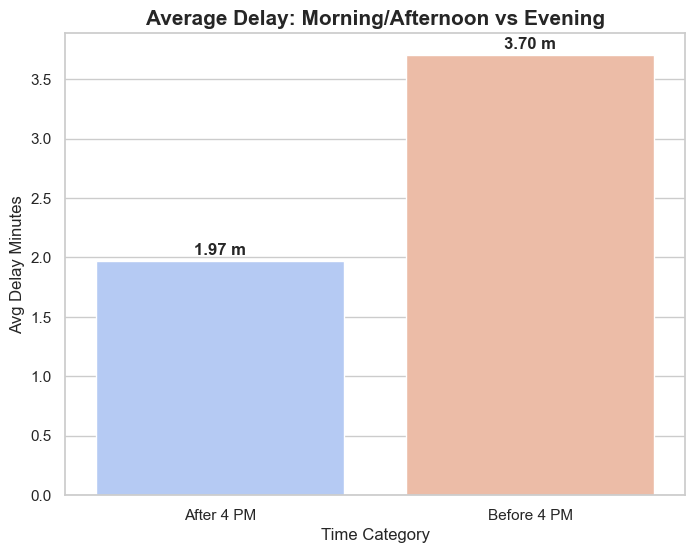

In [46]:
# ==========================================
# Q4: Delay Accumulation (Before vs After 4 PM)
# ==========================================

# 1. تصنيف الوقت
df['after_4pm_flag'] = df['departure_time'].dt.components.hours.apply(lambda h: 'After 4 PM' if h >= 16 else 'Before 4 PM')

# 2. حساب متوسط التأخير
time_delay_comp = df.groupby('after_4pm_flag')['delay_minutes'].mean().reset_index()

# 3. الرسم البياني
plt.figure(figsize=(8, 6))
sns.barplot(data=time_delay_comp, x='after_4pm_flag', y='delay_minutes', palette='coolwarm')

plt.title('Average Delay: Morning/Afternoon vs Evening', fontsize=15, fontweight='bold')
plt.ylabel('Avg Delay Minutes')
plt.xlabel('Time Category')

# إضافة الأرقام فوق الأعمدة
for index, row in time_delay_comp.iterrows():
    plt.text(index, row.delay_minutes + 0.05, f'{row.delay_minutes:.2f} m', ha='center', fontweight='bold')

plt.show()

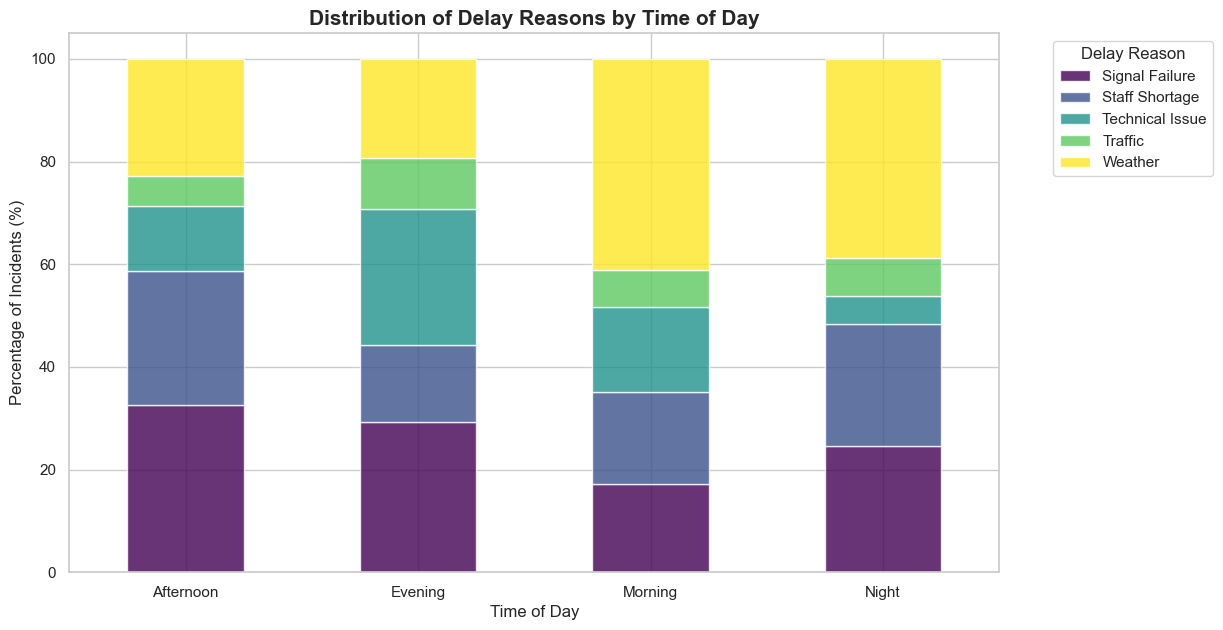

In [48]:
# ==========================================
# Q5: Delay Reasons by Time of Day
# ==========================================

# فلترة الرحلات اللي فيها مشاكل بس
disruptions = df[df['journey_status'].isin(['Delayed', 'Cancelled'])]

# عمل جدول متقاطع
reason_time_pivot = pd.crosstab(disruptions['time_of_day'], disruptions['reason_for_delay'], normalize='index') * 100

# الرسم البياني (Stacked Bar Chart)
reason_time_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', alpha=0.8)

plt.title('Distribution of Delay Reasons by Time of Day', fontsize=15, fontweight='bold')
plt.ylabel('Percentage of Incidents (%)')
plt.xlabel('Time of Day')
plt.xticks(rotation=0)
plt.legend(title='Delay Reason', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\754767039.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottlenecks['disruption_rate'], y=bottlenecks.index, palette='rocket')


NameError: name 'f' is not defined

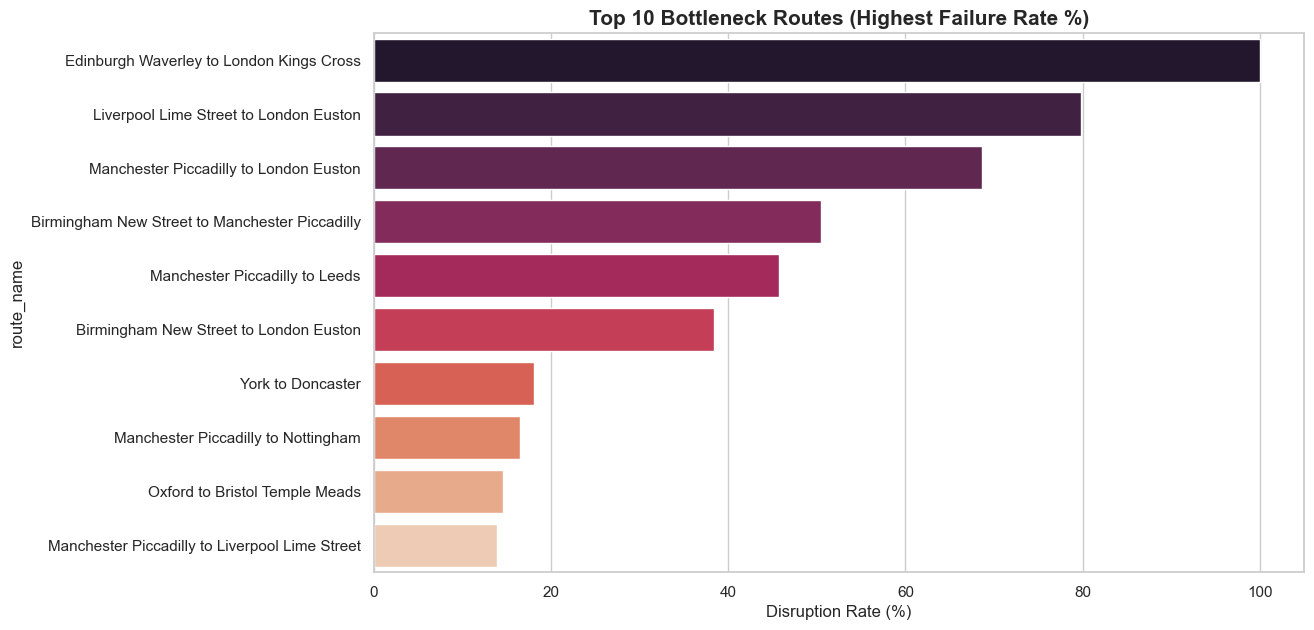

In [50]:
# ==========================================
# Q6: Bottleneck Routes (Highest Failure Rate)
# ==========================================

# 1. حساب معدل التعطل (تأخير + إلغاء) لكل مسار
route_perf = df.groupby('route_name').agg(
    total_trips=('transaction_id', 'count'),
    disruptions=('journey_status', lambda x: x.isin(['Delayed', 'Cancelled']).sum())
)
route_perf['disruption_rate'] = (route_perf['disruptions'] / route_perf['total_trips']) * 100

# 2. اختيار أسوأ 10 مسارات (عنق الزجاجة) - بشرط تكرار الرحلة > 50 مرة
bottlenecks = route_perf[route_perf['total_trips'] > 50].nlargest(10, 'disruption_rate')

# 3. الرسم البياني
plt.figure(figsize=(12, 7))
sns.barplot(x=bottlenecks['disruption_rate'], y=bottlenecks.index, palette='rocket')

plt.title('Top 10 Bottleneck Routes (Highest Failure Rate %)', fontsize=15, fontweight='bold')
plt.xlabel('Disruption Rate (%)')

# إضافة الأرقام على الأعمدة
f

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\554965965.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(route_profit.index, rotation=45, ha='right')


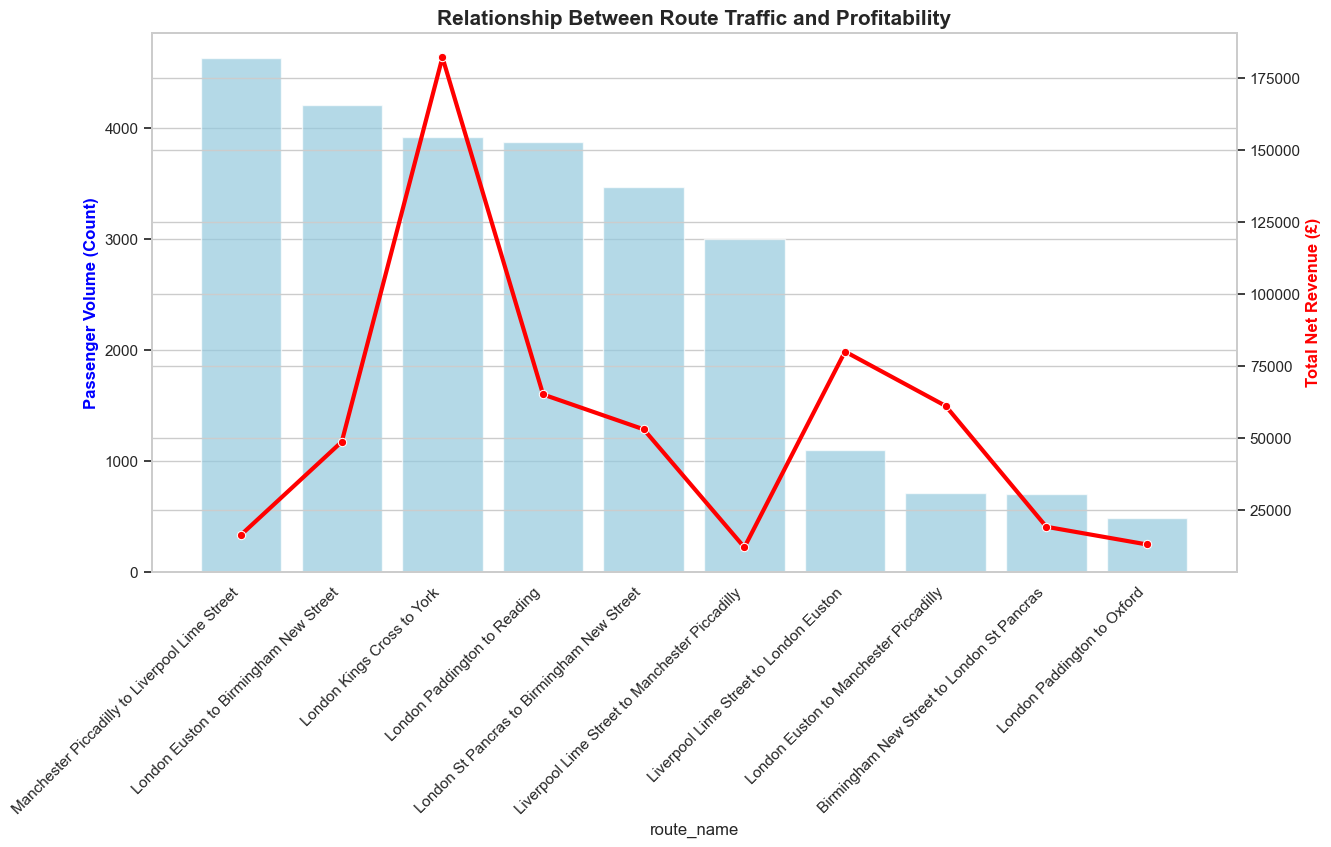

In [52]:
# ==========================================
# Q7: Traffic Volume vs. Profitability per Route
# ==========================================

# 1. تجميع البيانات لأكثر 10 مسارات زحمة
route_profit = df.groupby('route_name').agg(
    passenger_count=('transaction_id', 'count'),
    total_net_revenue=('net_revenue', 'sum')
).nlargest(10, 'passenger_count')

# 2. الرسم البياني بمحورين (Dual Axis)
fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

# الأعمدة للعدد
sns.barplot(x=route_profit.index, y=route_profit['passenger_count'], color='skyblue', ax=ax1, alpha=0.7)
# الخط للأرباح
sns.lineplot(x=route_profit.index, y=route_profit['total_net_revenue'], color='red', marker='o', ax=ax2, linewidth=3)

ax1.set_ylabel('Passenger Volume (Count)', color='blue', fontweight='bold')
ax2.set_ylabel('Total Net Revenue (£)', color='red', fontweight='bold')
plt.title('Relationship Between Route Traffic and Profitability', fontsize=15, fontweight='bold')
ax1.set_xticklabels(route_profit.index, rotation=45, ha='right')

plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\4192064772.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perf_counts.index, y=perf_counts.values, palette=colors)


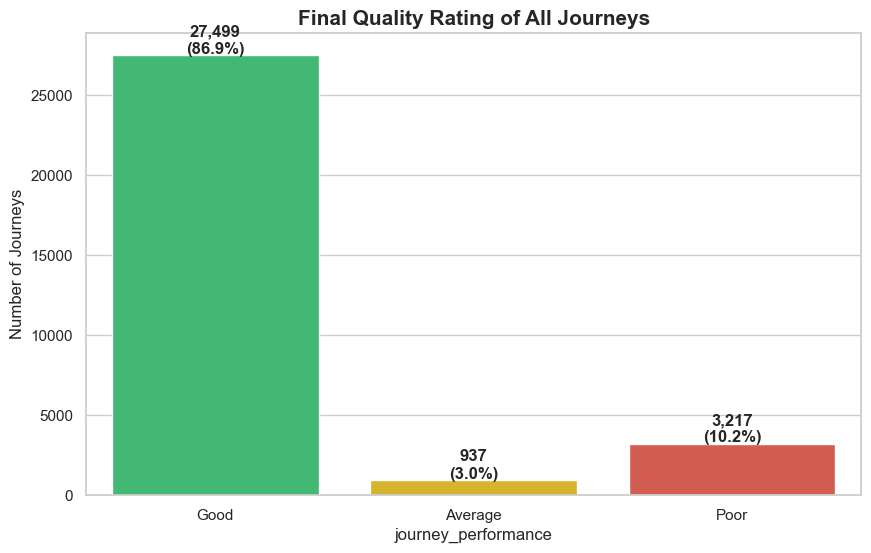

In [54]:
# ==========================================
# Q8: Journey Performance Distribution (Rating)
# ==========================================

# 1. حساب الأعداد
perf_counts = df['journey_performance'].value_counts().reindex(['Good', 'Average', 'Poor'])

# 2. الرسم البياني بألوان إشارة المرور
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#f1c40f', '#e74c3c']
sns.barplot(x=perf_counts.index, y=perf_counts.values, palette=colors)

plt.title('Final Quality Rating of All Journeys', fontsize=15, fontweight='bold')
plt.ylabel('Number of Journeys')

# إضافة الأرقام والنسب
total = perf_counts.sum()
for index, value in enumerate(perf_counts.values):
    pct = (value / total) * 100
    plt.text(index, value + 100, f'{value:,}\n({pct:.1f}%)', ha='center', fontweight='bold')

plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\911507319.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=rev_data, x='Metric', y='Value', palette=['#3498db', '#2ecc71', '#e74c3c'])


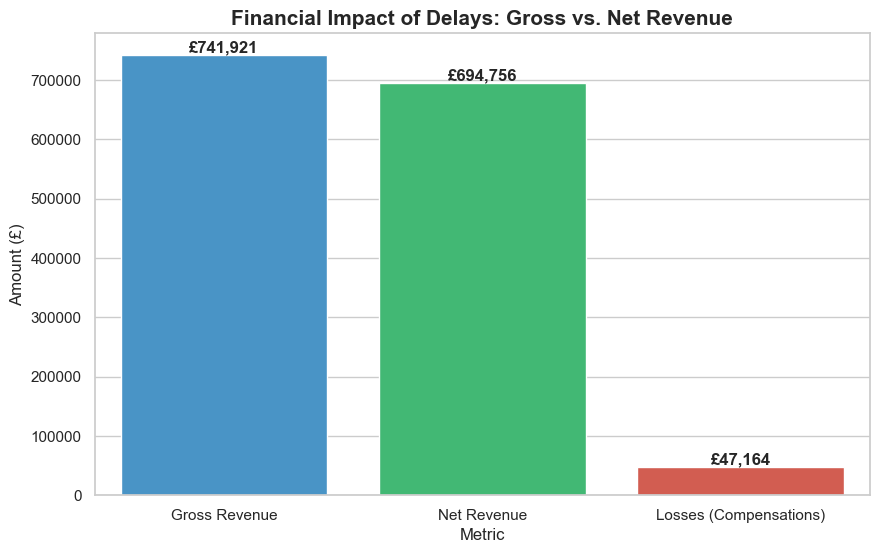

In [56]:
# ==========================================
# Q1: Gross Revenue vs. Net Revenue
# ==========================================

# 1. حساب القيم
total_gross = df['price'].sum()
total_net = df['net_revenue'].sum()
total_loss = total_gross - total_net

# 2. تجهيز البيانات للرسم
rev_data = pd.DataFrame({
    'Metric': ['Gross Revenue', 'Net Revenue', 'Losses (Compensations)'],
    'Value': [total_gross, total_net, total_loss]
})

# 3. الرسم البياني
plt.figure(figsize=(10, 6))
bars = sns.barplot(data=rev_data, x='Metric', y='Value', palette=['#3498db', '#2ecc71', '#e74c3c'])

plt.title('Financial Impact of Delays: Gross vs. Net Revenue', fontsize=15, fontweight='bold')
plt.ylabel('Amount (£)')

# إضافة الأرقام فوق الأعمدة
for p in bars.patches:
    bars.annotate(f'£{p.get_height():,.0f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='bottom', fontweight='bold')

plt.show()

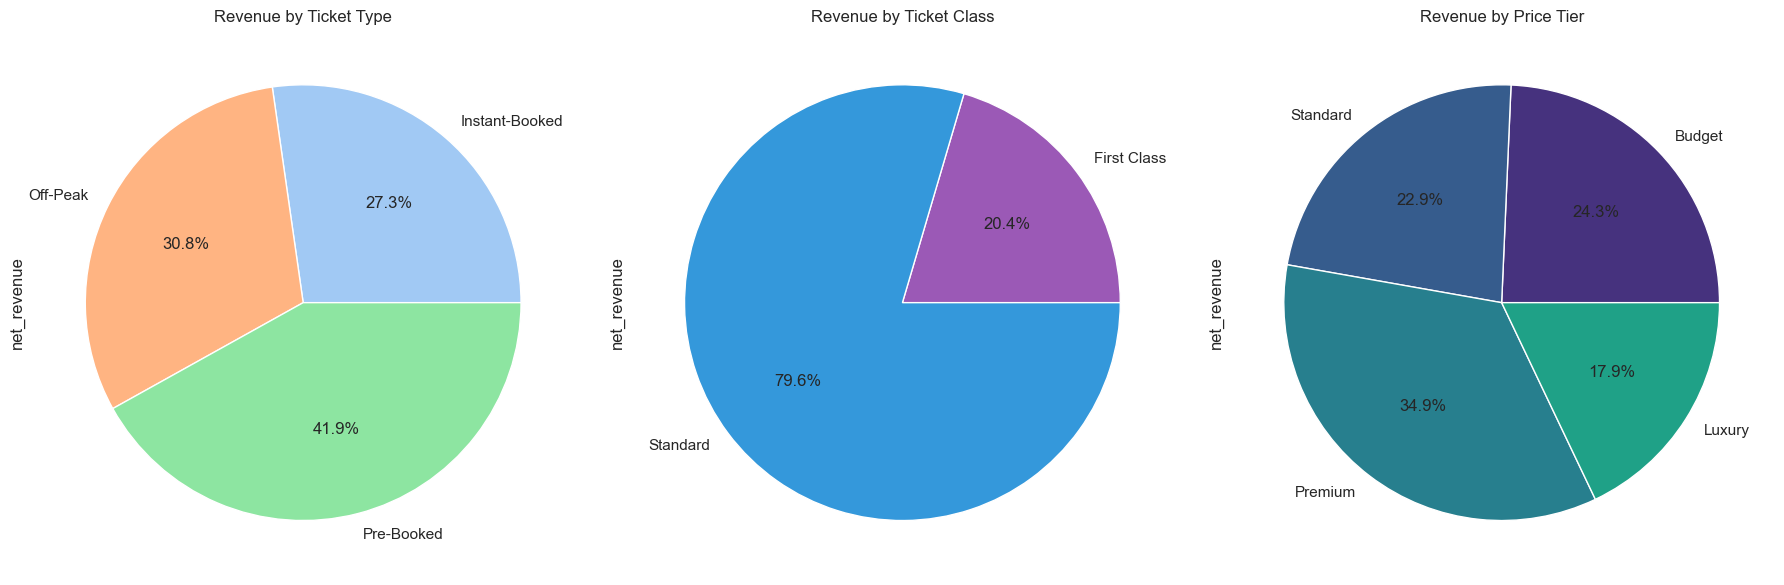

In [58]:
# ==========================================
# Q2: Revenue Breakdown (Type, Class, Tier)
# ==========================================

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# حسب نوع التذكرة
df.groupby('ticket_type')['net_revenue'].sum().plot(kind='pie', autopct='%1.1f%%', ax=ax1, colors=sns.color_palette('pastel'))
ax1.set_title('Revenue by Ticket Type')

# حسب الدرجة
df.groupby('ticket_class')['net_revenue'].sum().plot(kind='pie', autopct='%1.1f%%', ax=ax2, colors=['#9b59b6', '#3498db'])
ax2.set_title('Revenue by Ticket Class')

# حسب فئة السعر (Revenue Tier)
df.groupby('revenue_tier')['net_revenue'].sum().reindex(['Budget', 'Standard', 'Premium', 'Luxury']).plot(kind='pie', autopct='%1.1f%%', ax=ax3, colors=sns.color_palette('viridis'))
ax3.set_title('Revenue by Price Tier')

plt.tight_layout()
plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\3593186840.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Paid Refunds', 'Unclaimed (Saved)'], y=[paid_refunds, unclaimed_value], palette='Set2')


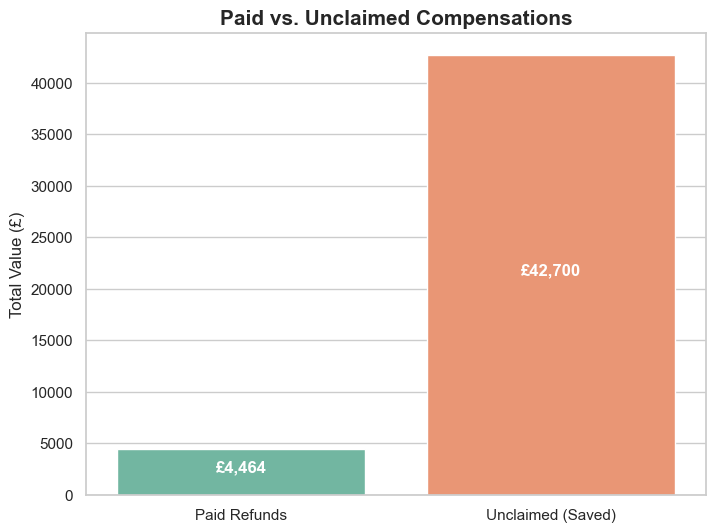

In [60]:
# ==========================================
# Q3: Unclaimed Compensation Value
# ==========================================

# الركاب اللي ليهم حق (تأخير >= 15 دقيقة) بس مطلبوش (Refund Request = No)
unclaimed_df = df[(df['delay_minutes'] >= 15) & (df['refund_request'] == 'No')]
unclaimed_value = (unclaimed_df['price'] * unclaimed_df['compensation_factor']).sum()

# الركاب اللي طلبوا وادفع لهم (تقريباً)
paid_refunds = (df[df['refund_request'] == 'Yes']['price'] * df[df['refund_request'] == 'Yes']['compensation_factor']).sum()

plt.figure(figsize=(8, 6))
sns.barplot(x=['Paid Refunds', 'Unclaimed (Saved)'], y=[paid_refunds, unclaimed_value], palette='Set2')

plt.title('Paid vs. Unclaimed Compensations', fontsize=15, fontweight='bold')
plt.ylabel('Total Value (£)')
plt.text(0, paid_refunds/2, f'£{paid_refunds:,.0f}', ha='center', color='white', fontweight='bold')
plt.text(1, unclaimed_value/2, f'£{unclaimed_value:,.0f}', ha='center', color='white', fontweight='bold')

plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\1594896264.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_by_type.values, y=loss_by_type.index, palette='Reds_r')


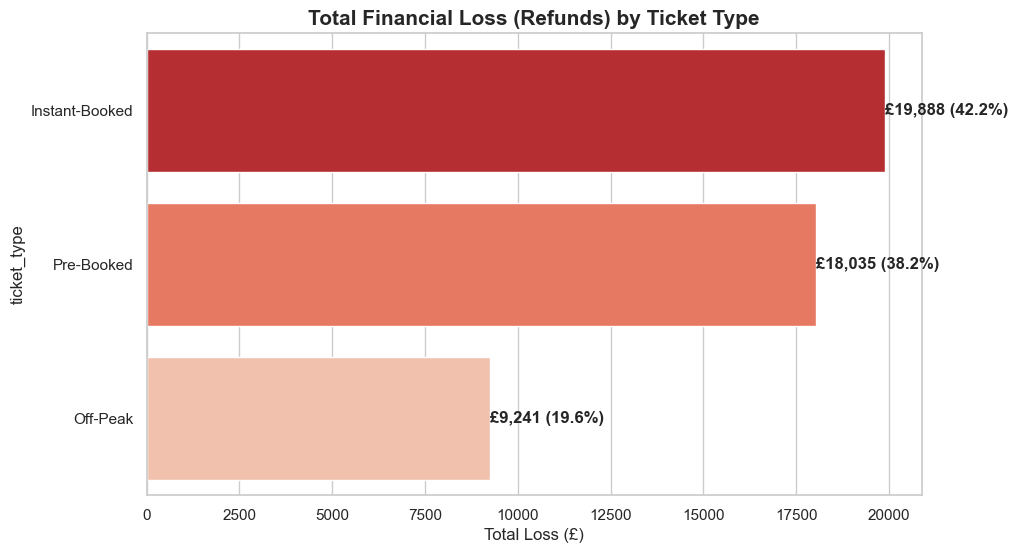

In [62]:
# ==========================================
# Q4: Financial Loss by Ticket Type
# ==========================================

# 1. حساب الخسارة لكل سطر
df['loss_amount'] = df['price'] - df['net_revenue']

# 2. تجميع الخسائر
loss_by_type = df.groupby('ticket_type')['loss_amount'].sum().sort_values(ascending=False)

# 3. الرسم البياني
plt.figure(figsize=(10, 6))
sns.barplot(x=loss_by_type.values, y=loss_by_type.index, palette='Reds_r')

plt.title('Total Financial Loss (Refunds) by Ticket Type', fontsize=15, fontweight='bold')
plt.xlabel('Total Loss (£)')

# إضافة الأرقام والنسب
total_loss = loss_by_type.sum()
for index, value in enumerate(loss_by_type.values):
    pct = (value / total_loss) * 100
    plt.text(value + 5, index, f'£{value:,.0f} ({pct:.1f}%)', va='center', fontweight='bold')

plt.show()

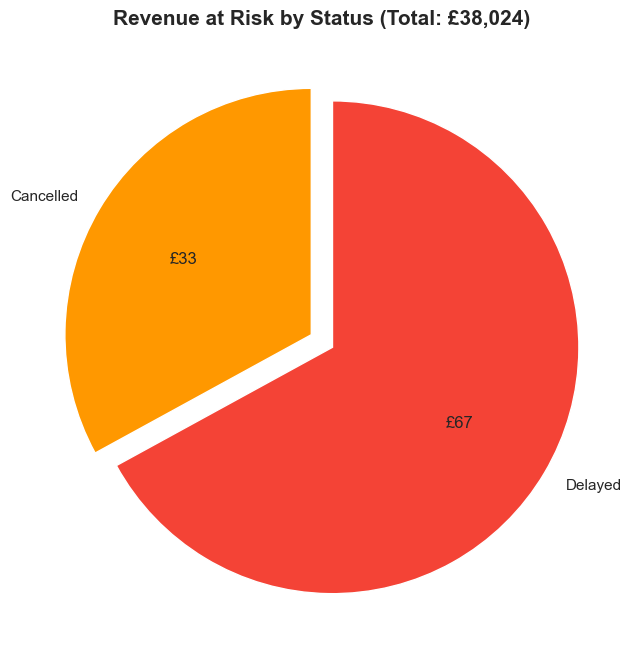

In [64]:
# ==========================================
# Q5: Total Revenue at Risk (Refund Claims)
# ==========================================

# حساب الإجمالي المطالب به
total_at_risk = df[df['refund_request'] == 'Yes']['price'].sum()

# توزيعه حسب الحالة (Delayed vs Cancelled)
risk_dist = df[df['refund_request'] == 'Yes'].groupby('journey_status')['price'].sum()

plt.figure(figsize=(8, 8))
plt.pie(risk_dist, labels=risk_dist.index, autopct='£%1.0f', 
        colors=['#FF9800', '#F44336'], startangle=90, explode=(0.05, 0.05))

plt.title(f'Revenue at Risk by Status (Total: £{total_at_risk:,.0f})', fontsize=15, fontweight='bold')
plt.show()

إجمالي قيمة التعويضات التي يجب على الشركة دفعها فعلياً: £4,464.00


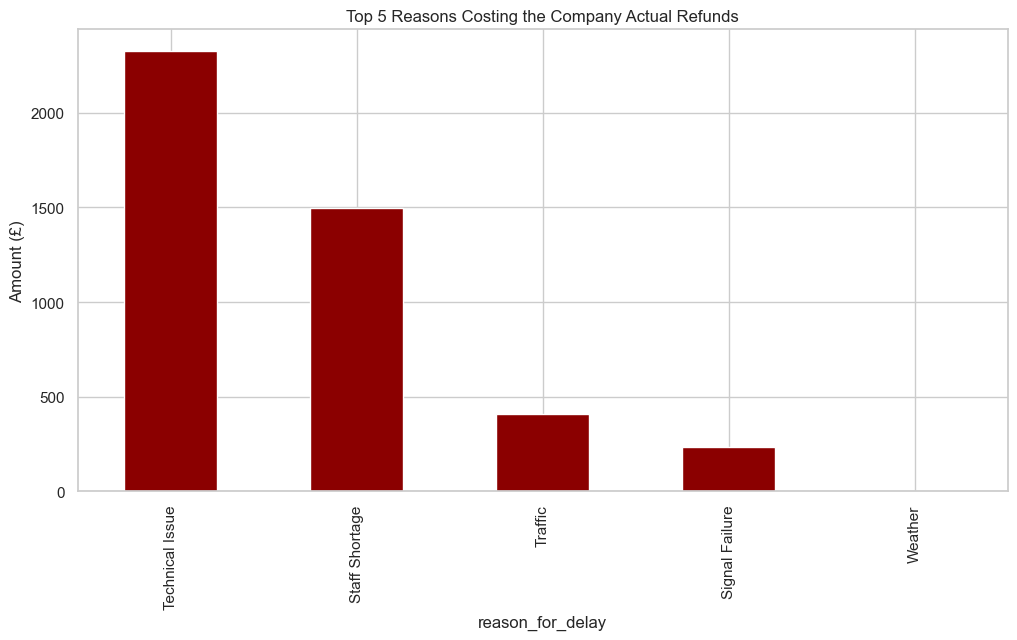

In [66]:
# ==========================================
# Q6: Total Actual Compensations Due
# ==========================================

# التعويض المستحق = السعر * الفاكتور (فقط للناس اللي طلبت Refund)
refunds_due = df[df['refund_request'] == 'Yes'].copy()
refunds_due['amount_due'] = refunds_due['price'] * refunds_due['compensation_factor']

total_due = refunds_due['amount_due'].sum()

print(f"إجمالي قيمة التعويضات التي يجب على الشركة دفعها فعلياً: £{total_due:,.2f}")

# عرض أعلى 5 أسباب أدت لهذه التعويضات
refunds_due.groupby('reason_for_delay')['amount_due'].sum().nlargest(5).plot(kind='bar', color='darkred')
plt.title('Top 5 Reasons Costing the Company Actual Refunds')
plt.ylabel('Amount (£)')
plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\306872037.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=refund_prob.index, y=refund_prob['prob_pct'], palette='viridis')


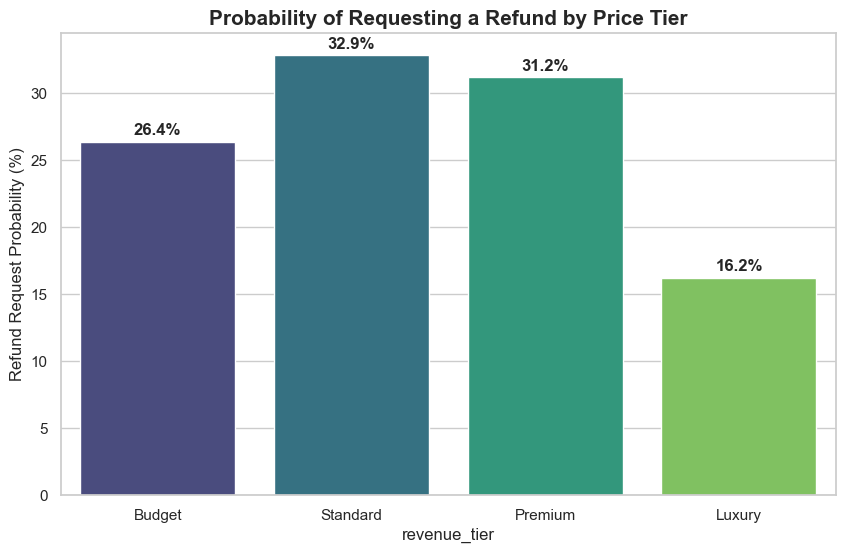

In [68]:
# ==========================================
# Q7: Ticket Price vs. Refund Probability
# ==========================================

# بنشوف كل فئة سعرية، نسبة الناس اللي طلبت Refund فيها كام
# نركز فقط على الرحلات اللي فيها مشاكل (Delayed or Cancelled) عشان المقارنة تكون عادلة
problematic_trips = df[df['journey_status'] != 'On Time'].copy()

refund_prob = problematic_trips.groupby('revenue_tier').agg(
    total_trips=('transaction_id', 'count'),
    refund_requests=('refund_request', lambda x: (x == 'Yes').sum())
)
refund_prob['prob_pct'] = (refund_prob['refund_requests'] / refund_prob['total_trips']) * 100

# ترتيب الفئات
refund_prob = refund_prob.reindex(['Budget', 'Standard', 'Premium', 'Luxury'])

plt.figure(figsize=(10, 6))
sns.barplot(x=refund_prob.index, y=refund_prob['prob_pct'], palette='viridis')

plt.title('Probability of Requesting a Refund by Price Tier', fontsize=15, fontweight='bold')
plt.ylabel('Refund Request Probability (%)')

for index, value in enumerate(refund_prob['prob_pct']):
    plt.text(index, value + 0.5, f'{value:.1f}%', ha='center', fontweight='bold')

plt.show()

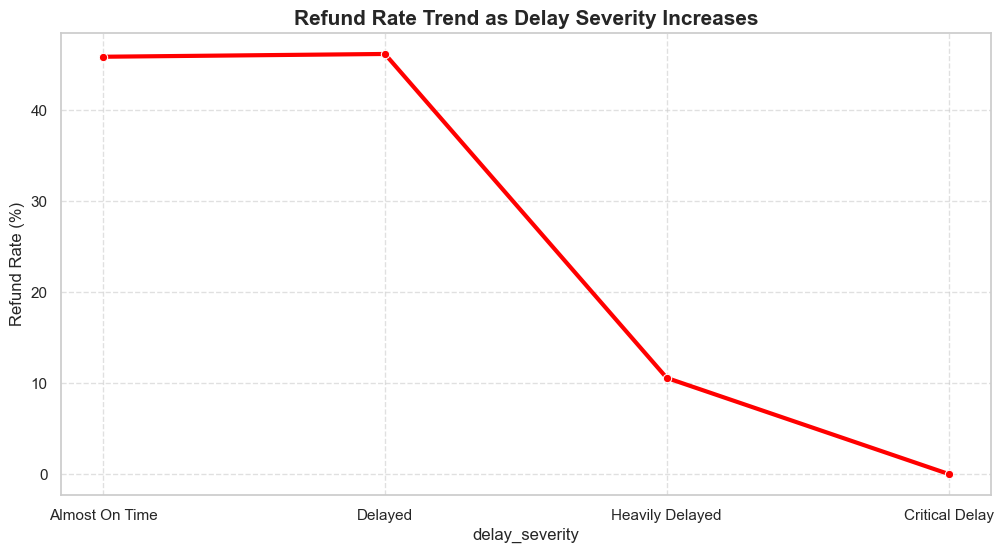

In [70]:
# ==========================================
# Q8: Delay Severity vs. Refund Requests
# ==========================================

# نأخذ الرحلات المتأخرة فقط
delayed_df = df[df['journey_status'] == 'Delayed'].copy()

severity_refund = delayed_df.groupby('delay_severity').agg(
    count=('transaction_id', 'count'),
    refunds=('refund_request', lambda x: (x == 'Yes').sum())
)
severity_refund['refund_rate'] = (severity_refund['refunds'] / severity_refund['count']) * 100

# ترتيب منطقي للشدة
sev_order = ['Almost On Time', 'Delayed', 'Heavily Delayed', 'Critical Delay']
severity_refund = severity_refund.reindex(sev_order)

plt.figure(figsize=(12, 6))
sns.lineplot(x=severity_refund.index, y=severity_refund['refund_rate'], marker='o', color='red', linewidth=3)

plt.title('Refund Rate Trend as Delay Severity Increases', fontsize=15, fontweight='bold')
plt.ylabel('Refund Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\2067481961.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pay_refund.index, y=pay_refund['rate'], palette='muted')


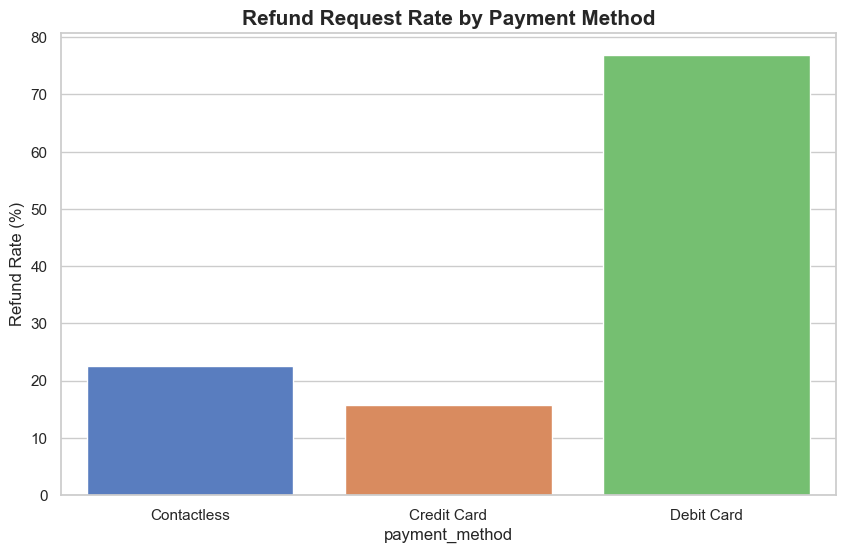

In [72]:
# ==========================================
# Q9: Payment Method vs. Refund Requests
# ==========================================

# حساب نسبة الاسترداد لكل طريقة دفع (في الرحلات المتعطلة)
pay_refund = problematic_trips.groupby('payment_method').agg(
    total=('transaction_id', 'count'),
    refunds=('refund_request', lambda x: (x == 'Yes').sum())
)
pay_refund['rate'] = (pay_refund['refunds'] / pay_refund['total']) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=pay_refund.index, y=pay_refund['rate'], palette='muted')

plt.title('Refund Request Rate by Payment Method', fontsize=15, fontweight='bold')
plt.ylabel('Refund Rate (%)')
plt.show()

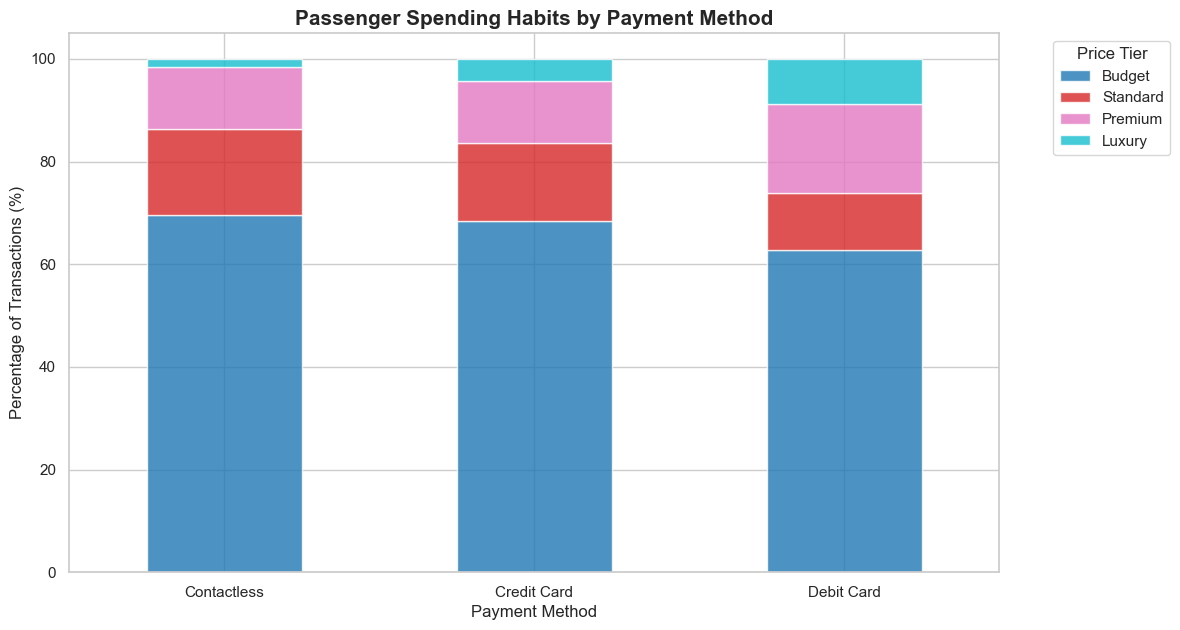

In [74]:
# ==========================================
# Q10: Payment Method vs. Revenue Tier Analysis
# ==========================================

# عمل جدول متقاطع (Pivot) لمعرفة توزيع الفئات المالية داخل كل طريقة دفع
pay_tier_pivot = pd.crosstab(df['payment_method'], df['revenue_tier'], normalize='index') * 100
pay_tier_pivot = pay_tier_pivot.reindex(columns=['Budget', 'Standard', 'Premium', 'Luxury'])

# الرسم البياني (Stacked Bar)
pay_tier_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab10', alpha=0.8)

plt.title('Passenger Spending Habits by Payment Method', fontsize=15, fontweight='bold')
plt.ylabel('Percentage of Transactions (%)')
plt.xlabel('Payment Method')
plt.xticks(rotation=0)
plt.legend(title='Price Tier', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\656234230.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=station_revenue.values, y=station_revenue.index, palette='Greens_r')


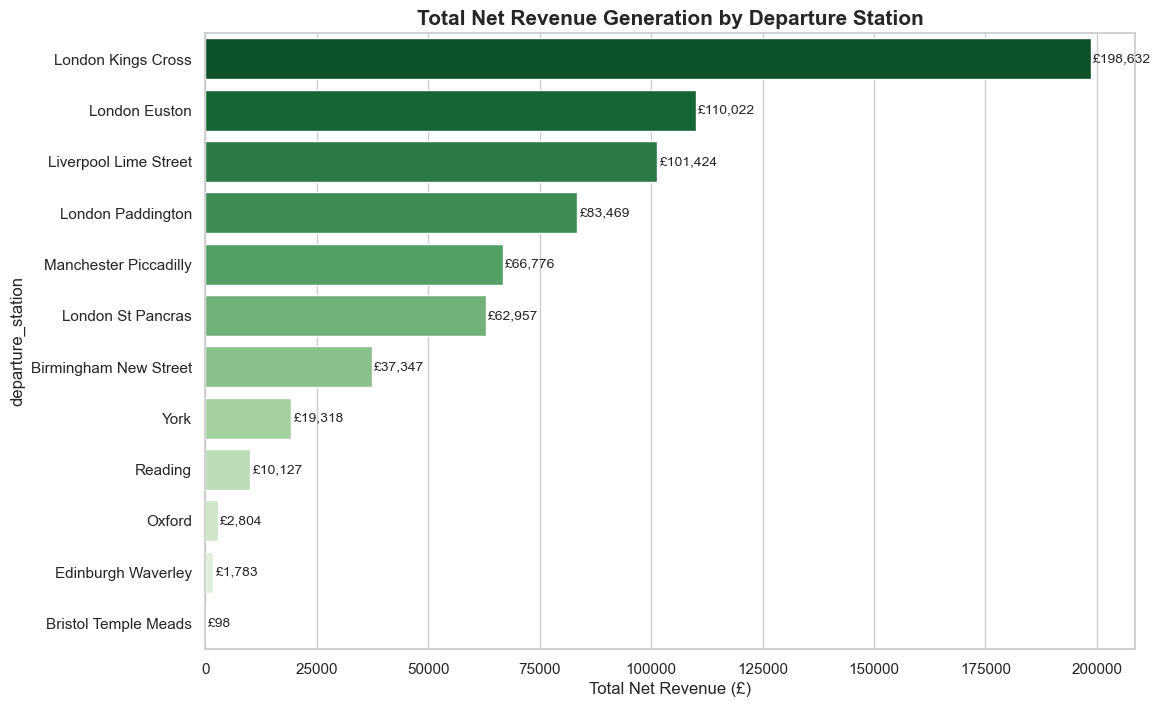

In [76]:
# ==========================================
# Q11: Total Net Revenue per Departure Station
# ==========================================

# حساب مجموع الصافي لكل محطة
station_revenue = df.groupby('departure_station')['net_revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=station_revenue.values, y=station_revenue.index, palette='Greens_r')

plt.title('Total Net Revenue Generation by Departure Station', fontsize=15, fontweight='bold')
plt.xlabel('Total Net Revenue (£)')

# إضافة أرقام الملايين/الآلاف
for index, value in enumerate(station_revenue.values):
    plt.text(value + 500, index, f'£{value:,.0f}', va='center', fontsize=10)

plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\949955557.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_routes.values, y=top_5_routes.index, palette='magma')


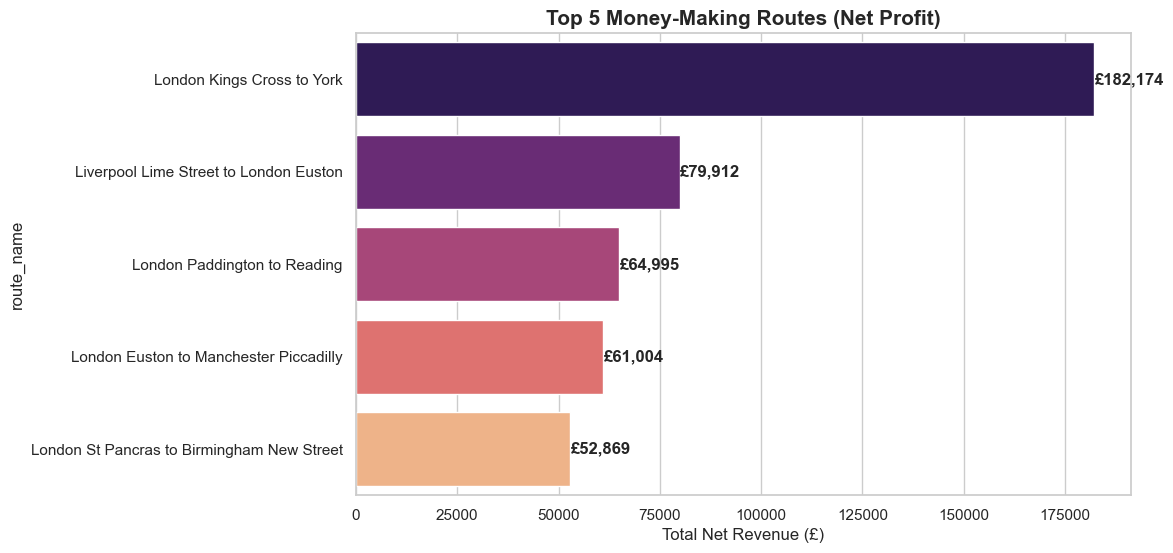

In [78]:
# ==========================================
# Q12: Top 5 Routes by Total Net Revenue
# ==========================================

top_5_routes = df.groupby('route_name')['net_revenue'].sum().nlargest(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_routes.values, y=top_5_routes.index, palette='magma')

plt.title('Top 5 Money-Making Routes (Net Profit)', fontsize=15, fontweight='bold')
plt.xlabel('Total Net Revenue (£)')

for index, value in enumerate(top_5_routes.values):
    plt.text(value + 100, index, f'£{value:,.0f}', va='center', fontweight='bold')

plt.show()

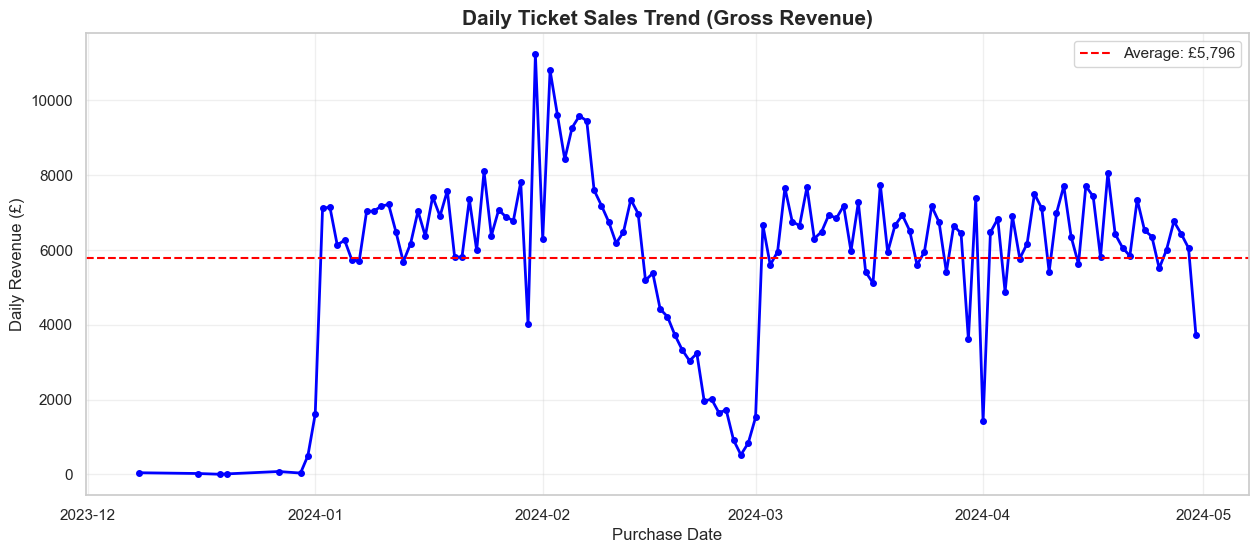

In [80]:
# ==========================================
# Q13: Daily Sales Revenue Trend
# ==========================================

# تجميع المبيعات حسب التاريخ
daily_sales = df.groupby('date_of_purchase')['price'].sum()

plt.figure(figsize=(15, 6))
plt.plot(daily_sales.index, daily_sales.values, color='blue', linewidth=2, marker='o', markersize=4)

# إضافة متوسط خط المبيعات
plt.axhline(daily_sales.mean(), color='red', linestyle='--', label=f'Average: £{daily_sales.mean():,.0f}')

plt.title('Daily Ticket Sales Trend (Gross Revenue)', fontsize=15, fontweight='bold')
plt.xlabel('Purchase Date')
plt.ylabel('Daily Revenue (£)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

إجمالي عدد التذاكر التي تم بيعها: 31,653


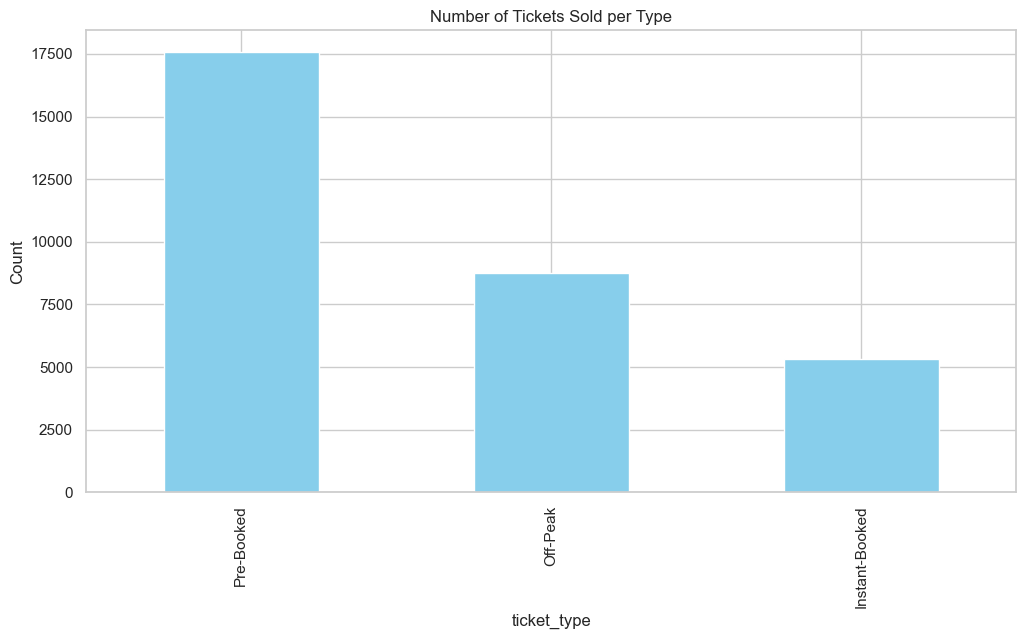

In [82]:
# ==========================================
# Q14: Total Ticket Sales Volume Overview
# ==========================================

print(f"إجمالي عدد التذاكر التي تم بيعها: {len(df):,}")

# توزيع المبيعات حسب نوع التذكرة (بشكل عددي)
ticket_counts = df['ticket_type'].value_counts()
ticket_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Tickets Sold per Type')
plt.ylabel('Count')
plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\2352072940.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_ticket.index, y=avg_price_ticket.values, palette='magma')


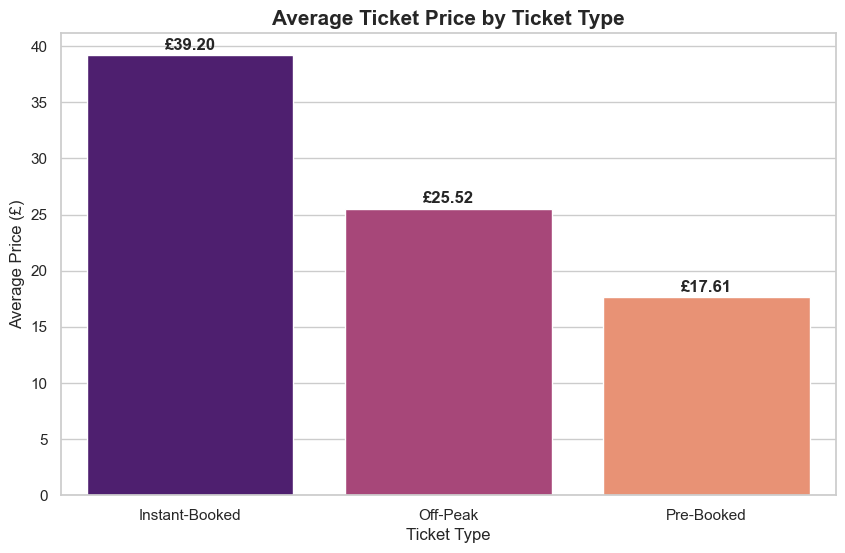

In [100]:
# ==========================================
# Q1: Ticket Type vs. Price Analysis
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# حساب متوسط السعر لكل نوع تذكرة
avg_price_ticket = df.groupby('ticket_type')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_price_ticket.index, y=avg_price_ticket.values, palette='magma')

plt.title('Average Ticket Price by Ticket Type', fontsize=15, fontweight='bold')
plt.ylabel('Average Price (£)')
plt.xlabel('Ticket Type')

# إضافة الأرقام فوق الأعمدة
for index, value in enumerate(avg_price_ticket.values):
    plt.text(index, value + 0.5, f'£{value:.2f}', ha='center', fontweight='bold')

plt.show()

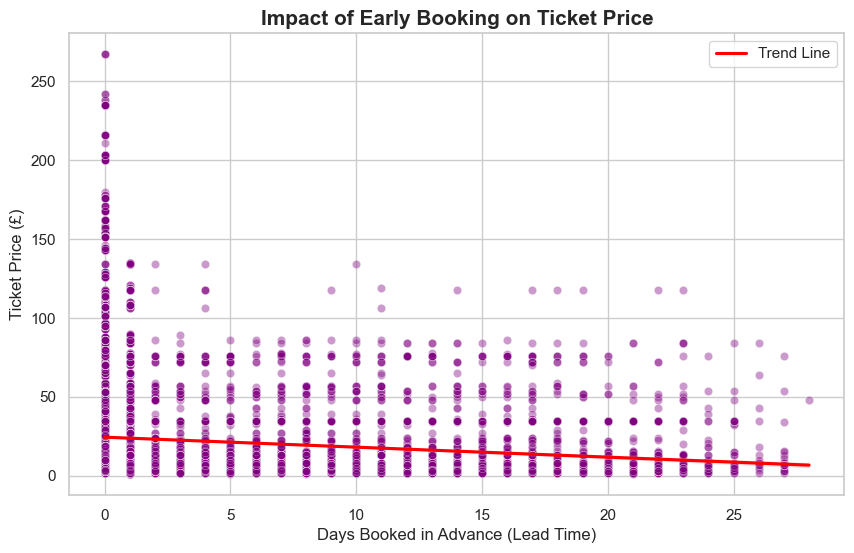

معامل الارتباط (Correlation) بين فترة الحجز والسعر: -0.08


In [102]:
# ==========================================
# Q1: Booking Lead Time vs. Ticket Price
# ==========================================

# 1. التأكد من حساب عمود lead_time_days (عشان نتفادى الإيرور)
if 'lead_time_days' not in df.columns:
    df['lead_time_days'] = (df['date_of_journey'] - df['date_of_purchase']).dt.days

# 2. رسم مبعثر (Scatter Plot) لمعرفة العلاقة
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='lead_time_days', y='price', alpha=0.4, color='purple')

# إضافة خط الاتجاه (Trend Line)
sns.regplot(data=df, x='lead_time_days', y='price', scatter=False, color='red', label='Trend Line')

plt.title('Impact of Early Booking on Ticket Price', fontsize=15, fontweight='bold')
plt.xlabel('Days Booked in Advance (Lead Time)')
plt.ylabel('Ticket Price (£)')
plt.legend()
plt.show()

# 3. حساب الارتباط الرقمي
correlation = df['lead_time_days'].corr(df['price'])
print(f"معامل الارتباط (Correlation) بين فترة الحجز والسعر: {correlation:.2f}")

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\3202141995.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=online_station, x='purchase_type', y='count', palette='viridis', ax=ax1)
C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\3202141995.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=online_station, x='purchase_type', y='avg_price', palette='magma', ax=ax2)


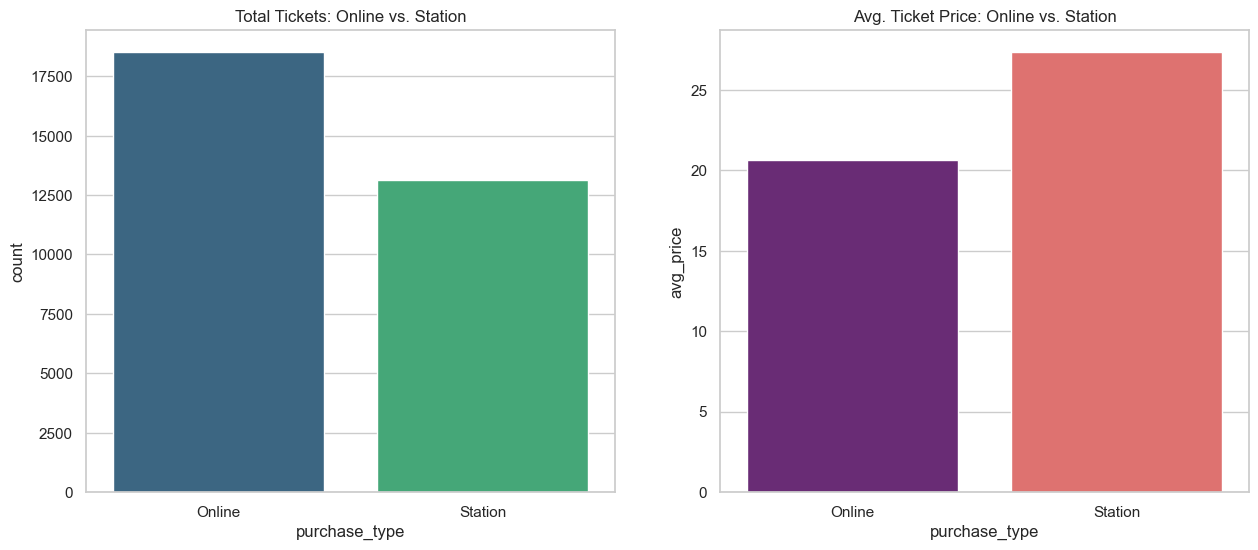

In [88]:
# ==========================================
# Q3: Purchase Type Analysis: Volume & Average Price
# ==========================================

# حساب العدد والمتوسط
online_station = df.groupby('purchase_type').agg(
    count=('transaction_id', 'count'),
    avg_price=('price', 'mean')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# الرسمة الأولى: العدد
sns.barplot(data=online_station, x='purchase_type', y='count', palette='viridis', ax=ax1)
ax1.set_title('Total Tickets: Online vs. Station')

# الرسمة الثانية: متوسط السعر
sns.barplot(data=online_station, x='purchase_type', y='avg_price', palette='magma', ax=ax2)
ax2.set_title('Avg. Ticket Price: Online vs. Station')

plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\4098420508.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sensitivity.index, y=sensitivity['refund_rate'], palette='cool')


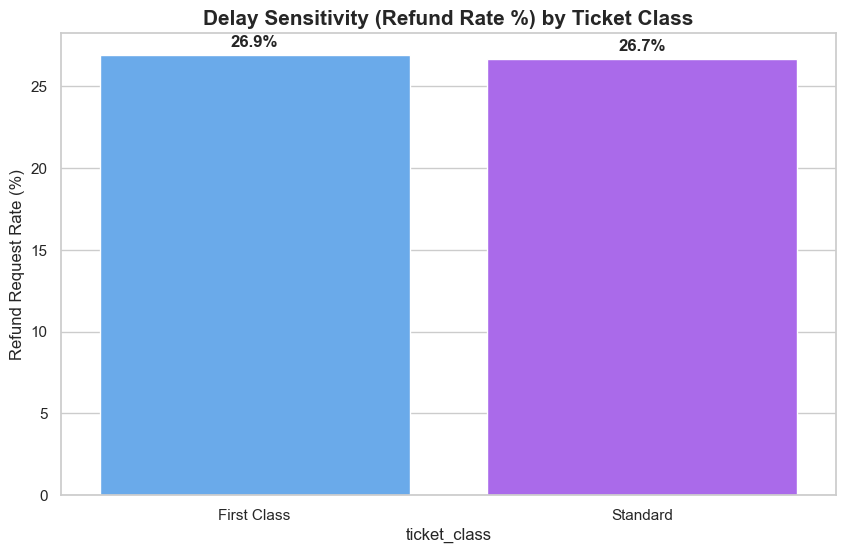

In [90]:
# ==========================================
# Q4: Delay Sensitivity: First Class vs. Standard
# ==========================================

# نأخذ فقط الرحلات التي تعرضت لمشاكل
disrupted = df[df['journey_status'] != 'On Time'].copy()

sensitivity = disrupted.groupby('ticket_class').agg(
    total=('transaction_id', 'count'),
    refunds=('refund_request', lambda x: (x == 'Yes').sum())
)
sensitivity['refund_rate'] = (sensitivity['refunds'] / sensitivity['total']) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=sensitivity.index, y=sensitivity['refund_rate'], palette='cool')

plt.title('Delay Sensitivity (Refund Rate %) by Ticket Class', fontsize=15, fontweight='bold')
plt.ylabel('Refund Request Rate (%)')

for index, value in enumerate(sensitivity['refund_rate']):
    plt.text(index, value + 0.5, f'{value:.1f}%', ha='center', fontweight='bold')

plt.show()

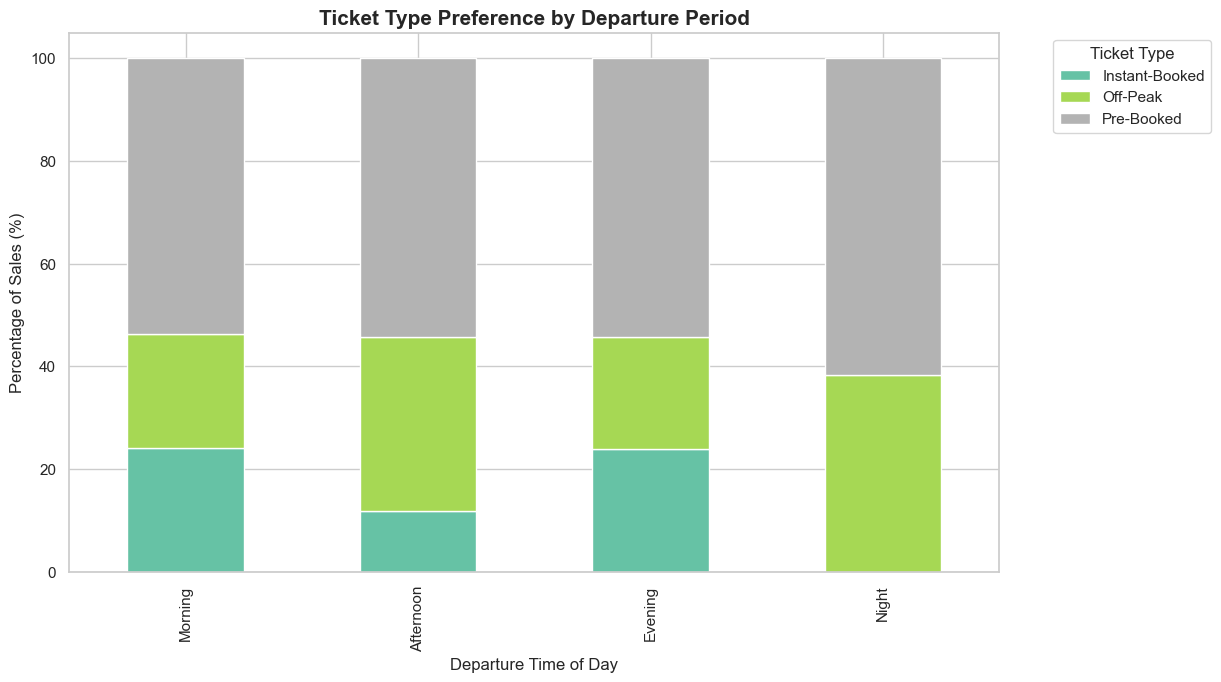

In [92]:
# ==========================================
# Q5: Departure Period vs. Ticket Type Selection
# ==========================================

# عمل جدول متقاطع
time_ticket_pivot = pd.crosstab(df['time_of_day'], df['ticket_type'], normalize='index') * 100
time_ticket_pivot = time_ticket_pivot.reindex(['Morning', 'Afternoon', 'Evening', 'Night'])

# الرسم البياني
time_ticket_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='Set2')

plt.title('Ticket Type Preference by Departure Period', fontsize=15, fontweight='bold')
plt.ylabel('Percentage of Sales (%)')
plt.xlabel('Departure Time of Day')
plt.legend(title='Ticket Type', bbox_to_anchor=(1.05, 1))
plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\1343608496.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=severity_counts.index, y=severity_counts.values, palette='YlOrRd')


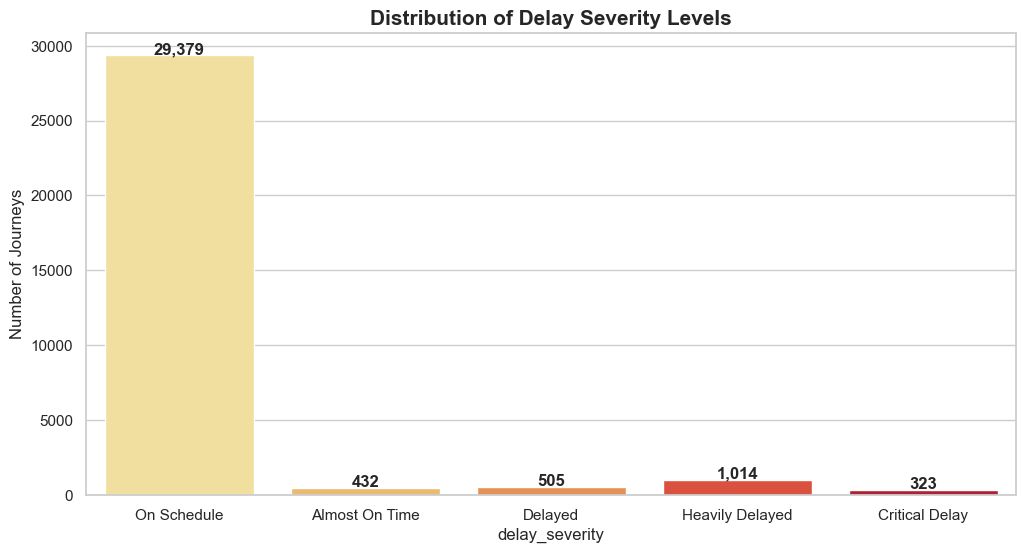

In [104]:
# ==========================================
# Q1: Distribution of Delay Severity
# ==========================================

severity_counts = df['delay_severity'].value_counts()
order = ['On Schedule', 'Almost On Time', 'Delayed', 'Heavily Delayed', 'Critical Delay']
severity_counts = severity_counts.reindex(order).fillna(0)

plt.figure(figsize=(12, 6))
sns.barplot(x=severity_counts.index, y=severity_counts.values, palette='YlOrRd')

plt.title('Distribution of Delay Severity Levels', fontsize=15, fontweight='bold')
plt.ylabel('Number of Journeys')
for index, value in enumerate(severity_counts.values):
    plt.text(index, value + 100, f'{value:,}', ha='center', fontweight='bold')
plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\3014550926.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delay_reason.values, y=avg_delay_reason.index, palette='flare')


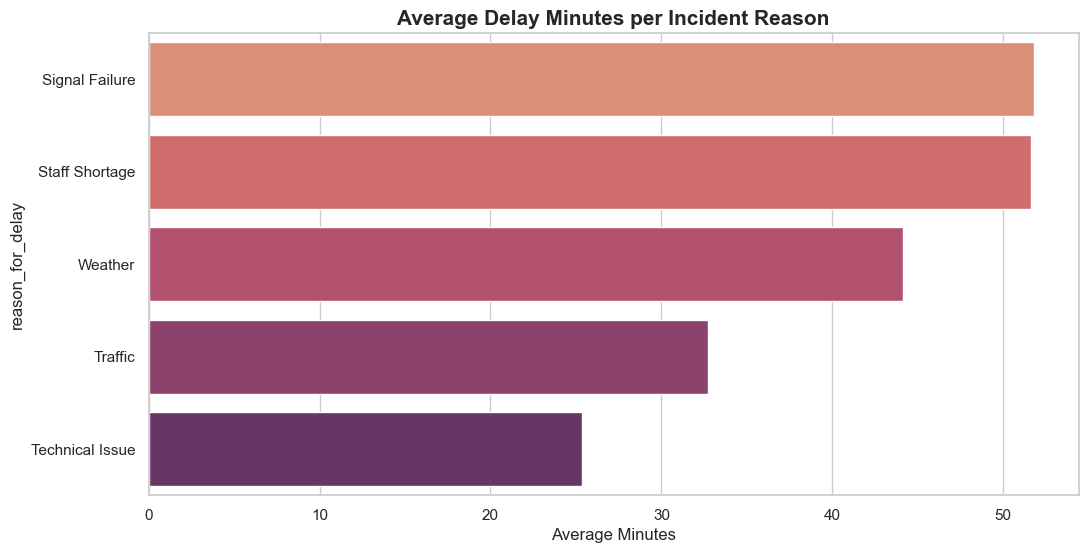

In [106]:
# ==========================================
# Q2: Average Delay Duration per Reason
# ==========================================

avg_delay_reason = df[df['journey_status'] == 'Delayed'].groupby('reason_for_delay')['delay_minutes'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_delay_reason.values, y=avg_delay_reason.index, palette='flare')

plt.title('Average Delay Minutes per Incident Reason', fontsize=15, fontweight='bold')
plt.xlabel('Average Minutes')
plt.show()

أقصى مدة تأخير مسجلة قبل وصول القطر: 180.0 دقيقة


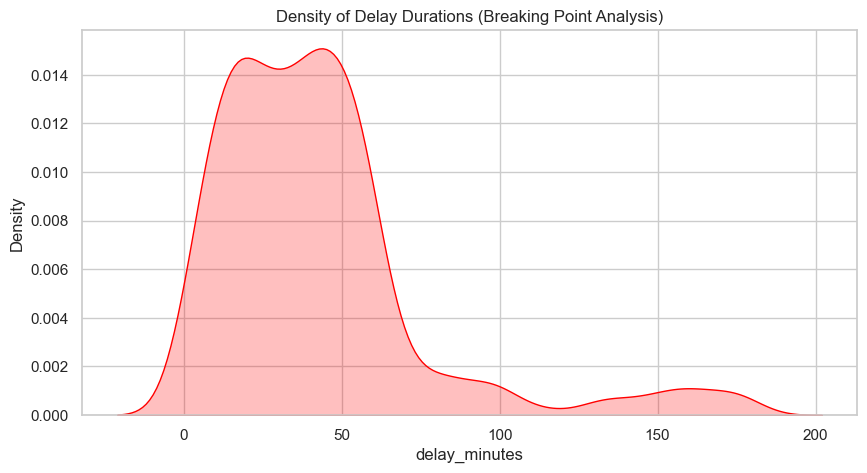

In [108]:
# ==========================================
# Q3: Max Delays vs. Cancellations Threshold
# ==========================================

max_delay = df[df['journey_status'] == 'Delayed']['delay_minutes'].max()
print(f"أقصى مدة تأخير مسجلة قبل وصول القطر: {max_delay:.1f} دقيقة")

# رسم توزيع دقائق التأخير لرؤية أين ينتهي "نفس" الشركة
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['delay_minutes'] > 0]['delay_minutes'], fill=True, color='red')
plt.title('Density of Delay Durations (Breaking Point Analysis)')
plt.show()

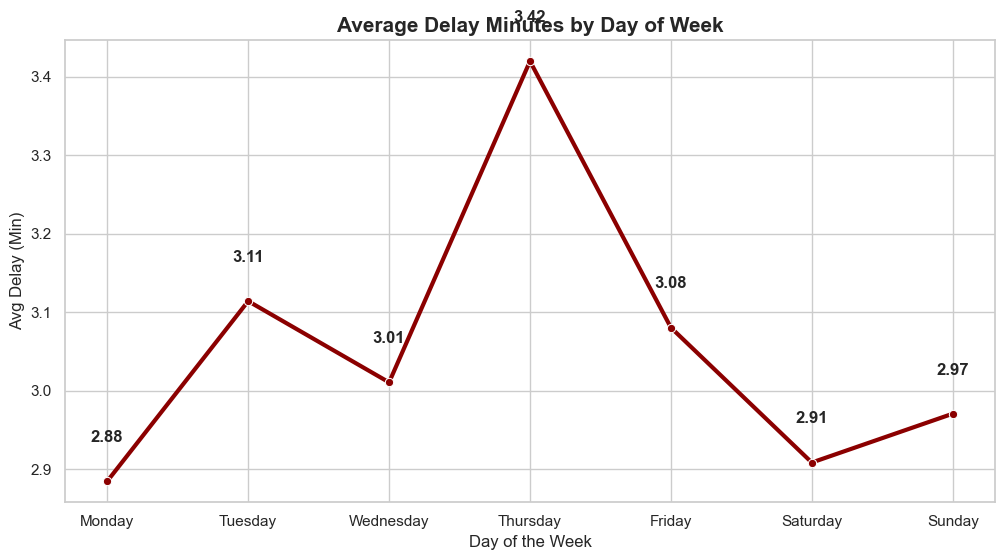

In [116]:
# ==========================================
# Q4: Weekly Delay Trend
# ==========================================

# 1. التأكد من وجود عمود day_name (حسابه لو مش موجود)
if 'day_name' not in df.columns:
    df['day_name'] = df['date_of_journey'].dt.day_name()

# 2. ترتيب الأيام منطقياً
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_delay = df.groupby('day_name')['delay_minutes'].mean().reindex(day_order)

# 3. الرسم البياني
plt.figure(figsize=(12, 6))
sns.lineplot(x=weekly_delay.index, y=weekly_delay.values, marker='o', color='darkred', linewidth=3)

# إضافة الأرقام فوق النقط
for x, y in enumerate(weekly_delay.values):
    plt.text(x, y + 0.05, f'{y:.2f}', ha='center', fontweight='bold')

plt.title('Average Delay Minutes by Day of Week', fontsize=15, fontweight='bold')
plt.ylabel('Avg Delay (Min)')
plt.xlabel('Day of the Week')
plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\647675205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_delays.values, y=weather_delays.index, palette='Blues_r')


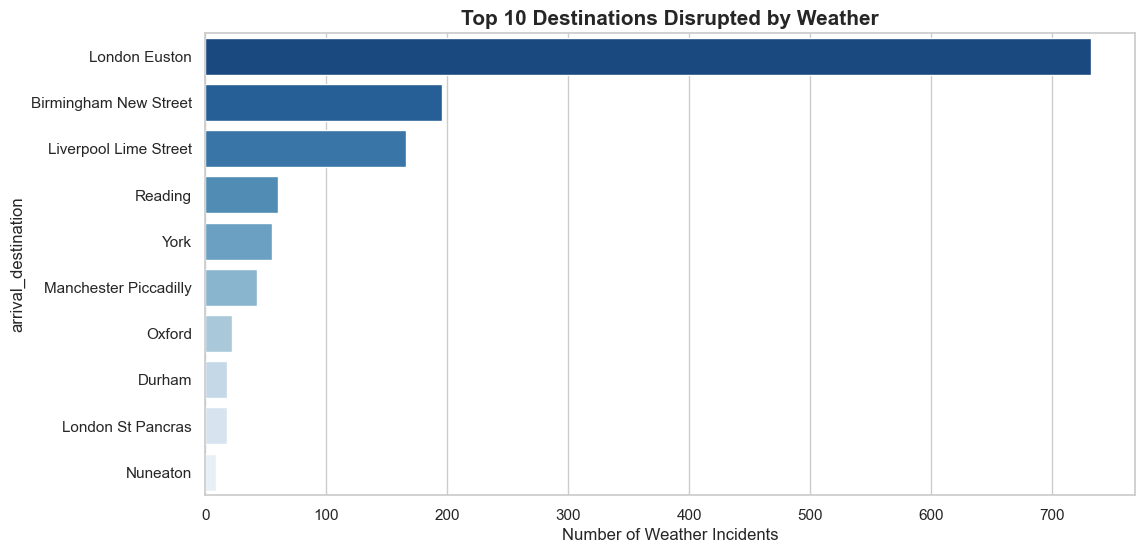

In [112]:
# ==========================================
# Q5: Top Destinations Affected by Weather
# ==========================================

weather_delays = df[df['reason_for_delay'] == 'Weather'].groupby('arrival_destination').size().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=weather_delays.values, y=weather_delays.index, palette='Blues_r')
plt.title('Top 10 Destinations Disrupted by Weather', fontsize=15, fontweight='bold')
plt.xlabel('Number of Weather Incidents')
plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\2623844902.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=time_perf.index, y=time_perf['on_time_rate'], palette='Greens_d')


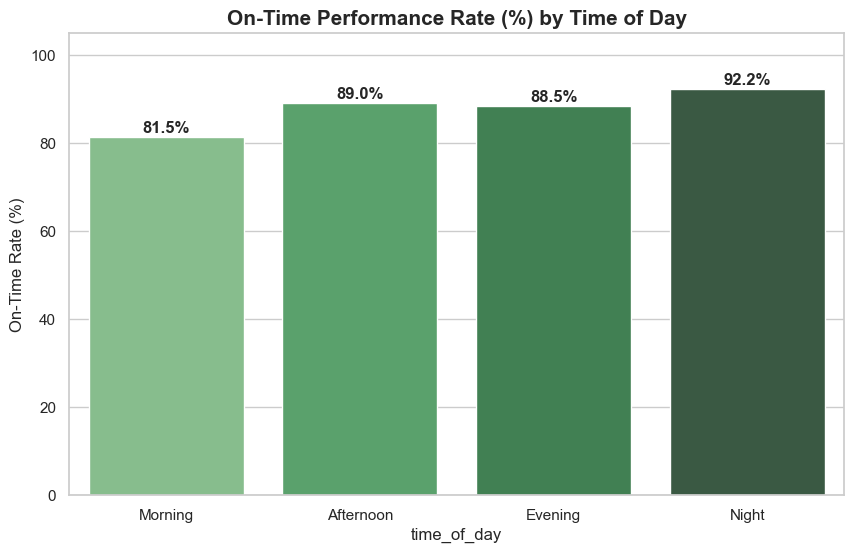

In [118]:
# ==========================================
# Q6: Performance Trend by Time of Day
# ==========================================

# 1. حساب نسبة الانضباط لكل فترة
time_perf = df.groupby('time_of_day').agg(
    total=('transaction_id', 'count'),
    on_time=('is_on_time_flag', 'sum')
)
time_perf['on_time_rate'] = (time_perf['on_time'] / time_perf['total']) * 100

# 2. ترتيب الفترات زمنياً
order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_perf = time_perf.reindex(order)

# 3. الرسم البياني
plt.figure(figsize=(10, 6))
sns.barplot(x=time_perf.index, y=time_perf['on_time_rate'], palette='Greens_d')

plt.title('On-Time Performance Rate (%) by Time of Day', fontsize=15, fontweight='bold')
plt.ylabel('On-Time Rate (%)')
plt.ylim(0, 105)

for index, value in enumerate(time_perf['on_time_rate']):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center', fontweight='bold')

plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\3922419139.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=peak_impact, x='peak_hour_flag', y='total_revenue', palette='coolwarm', ax=ax1)
C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\3922419139.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=peak_impact, x='peak_hour_flag', y='avg_delay', palette='viridis', ax=ax2)


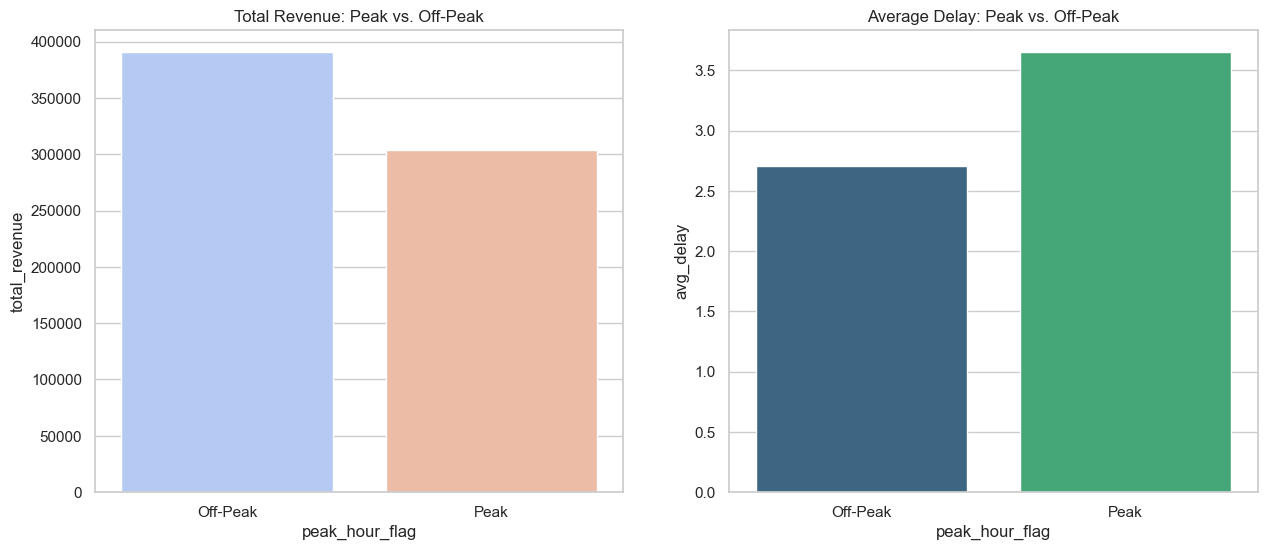

In [120]:
# ==========================================
# Q7: Peak Hours Impact: Revenue vs. Delay
# ==========================================

peak_impact = df.groupby('peak_hour_flag').agg(
    avg_delay=('delay_minutes', 'mean'),
    total_revenue=('net_revenue', 'sum')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# الأرباح
sns.barplot(data=peak_impact, x='peak_hour_flag', y='total_revenue', palette='coolwarm', ax=ax1)
ax1.set_title('Total Revenue: Peak vs. Off-Peak')

# التأخير
sns.barplot(data=peak_impact, x='peak_hour_flag', y='avg_delay', palette='viridis', ax=ax2)
ax2.set_title('Average Delay: Peak vs. Off-Peak')

plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\3748830530.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekend_perf.index, y=weekend_perf.values, palette='Set2')


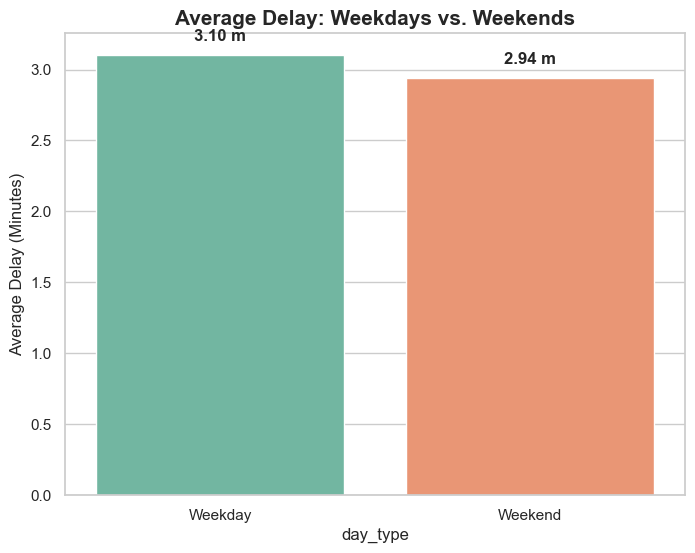

In [122]:
# ==========================================
# Q8: Weekend Effect on Delay Duration
# ==========================================

weekend_perf = df.groupby('day_type')['delay_minutes'].mean()

plt.figure(figsize=(8, 6))
sns.barplot(x=weekend_perf.index, y=weekend_perf.values, palette='Set2')

plt.title('Average Delay: Weekdays vs. Weekends', fontsize=15, fontweight='bold')
plt.ylabel('Average Delay (Minutes)')

for index, value in enumerate(weekend_perf.values):
    plt.text(index, value + 0.1, f'{value:.2f} m', ha='center', fontweight='bold')

plt.show()

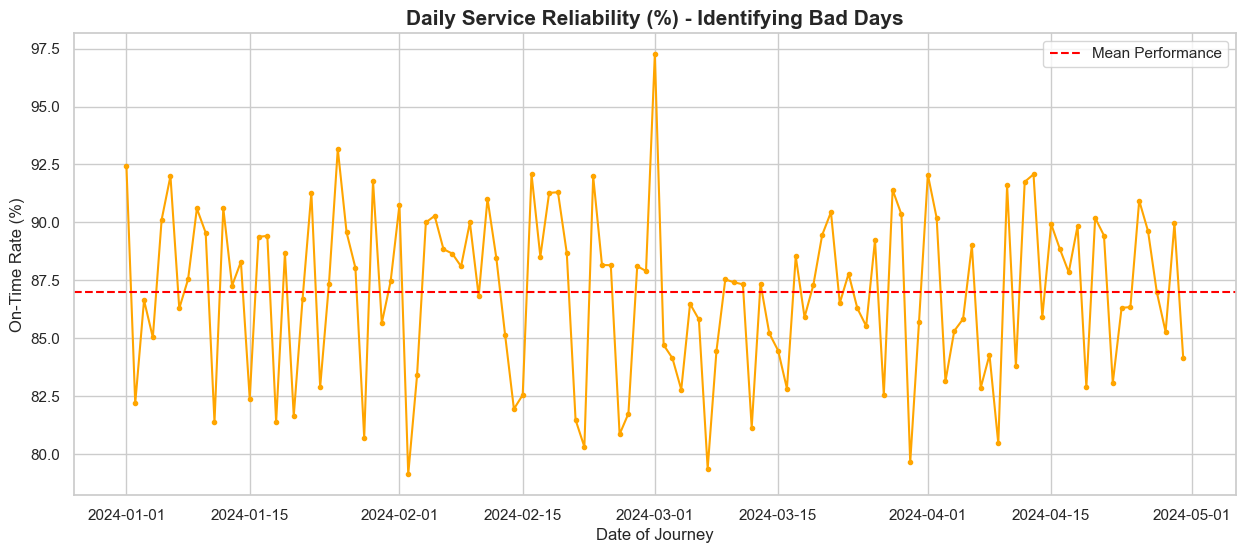

In [124]:
# ==========================================
# Q9: Daily Performance Dips (Outlier Detection)
# ==========================================

daily_perf = df.groupby('date_of_journey')['is_on_time_flag'].mean() * 100

plt.figure(figsize=(15, 6))
plt.plot(daily_perf.index, daily_perf.values, color='orange', marker='o', markersize=3)
plt.axhline(daily_perf.mean(), color='red', linestyle='--', label='Mean Performance')

plt.title('Daily Service Reliability (%) - Identifying Bad Days', fontsize=15, fontweight='bold')
plt.xlabel('Date of Journey')
plt.ylabel('On-Time Rate (%)')
plt.legend()
plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\2714465288.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='journey_performance', y='price', order=['Good', 'Average', 'Poor'], palette='Set2')


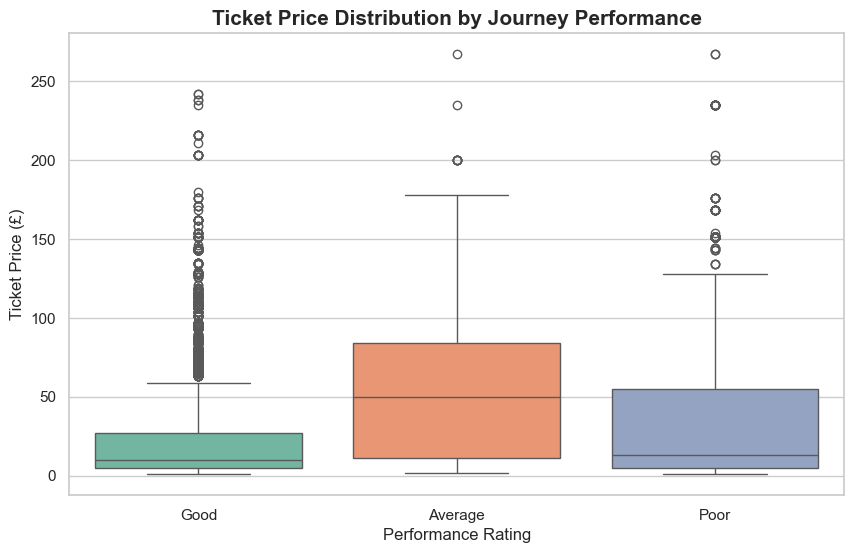

In [126]:
# ==========================================
# Q10: Price vs. Performance Correlation
# ==========================================

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='journey_performance', y='price', order=['Good', 'Average', 'Poor'], palette='Set2')

plt.title('Ticket Price Distribution by Journey Performance', fontsize=15, fontweight='bold')
plt.xlabel('Performance Rating')
plt.ylabel('Ticket Price (£)')
plt.show()

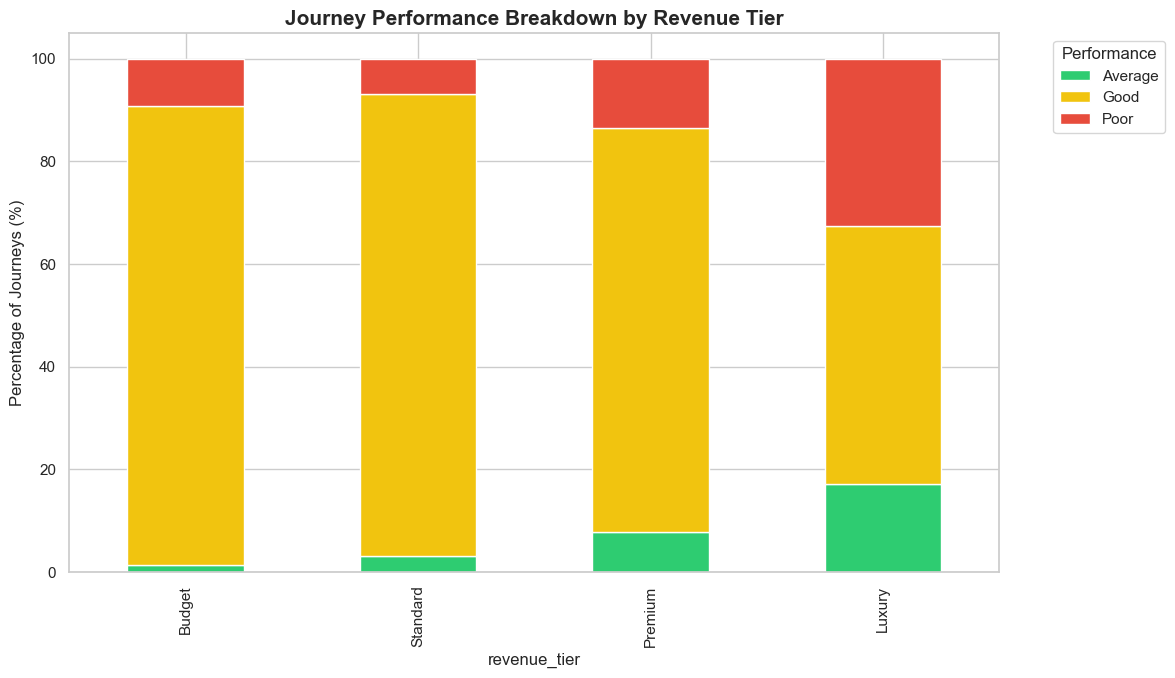

In [128]:
# ==========================================
# Q11: Revenue Tier vs. Journey Performance
# ==========================================

tier_perf_pivot = pd.crosstab(df['revenue_tier'], df['journey_performance'], normalize='index') * 100
tier_perf_pivot = tier_perf_pivot.reindex(['Budget', 'Standard', 'Premium', 'Luxury'])

tier_perf_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#2ecc71', '#f1c40f', '#e74c3c'])

plt.title('Journey Performance Breakdown by Revenue Tier', fontsize=15, fontweight='bold')
plt.ylabel('Percentage of Journeys (%)')
plt.legend(title='Performance', bbox_to_anchor=(1.05, 1))
plt.show()

C:\Users\osm24\AppData\Local\Temp\ipykernel_24016\1297848094.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ticket_delay.index, y=ticket_delay.values, palette='plasma')


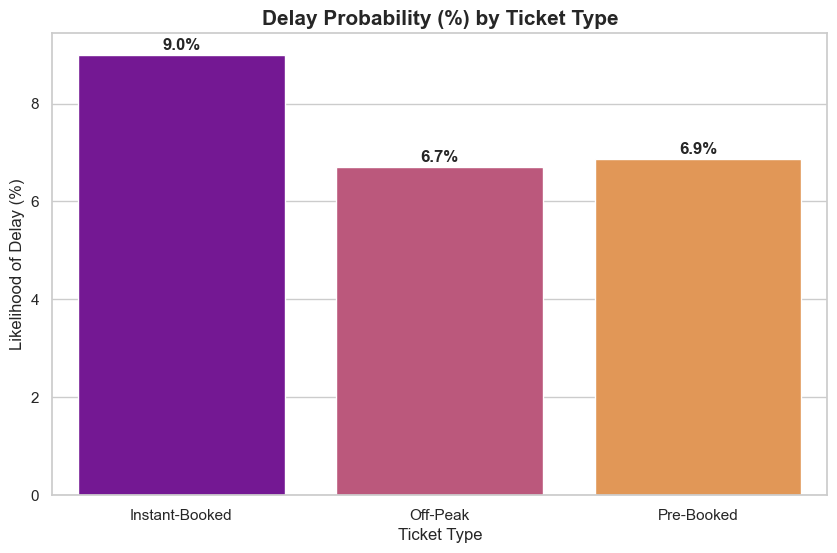

In [134]:
# ==========================================
# Q12: Ticket Type vs. Delay Probability
# ==========================================

# 1. حساب نسبة التأخير لكل نوع تذكرة
# النسبة = متوسط الـ Flag (بيدينا النسبة المئوية للتأخير)
ticket_delay = df.groupby('ticket_type')['is_delayed_flag'].mean() * 100

# 2. الرسم البياني
plt.figure(figsize=(10, 6))
sns.barplot(x=ticket_delay.index, y=ticket_delay.values, palette='plasma')

plt.title('Delay Probability (%) by Ticket Type', fontsize=15, fontweight='bold')
plt.ylabel('Likelihood of Delay (%)')
plt.xlabel('Ticket Type')

# إضافة النسب المئوية فوق الأعمدة
for index, value in enumerate(ticket_delay.values):
    plt.text(index, value + 0.1, f'{value:.1f}%', ha='center', fontweight='bold')

plt.show()

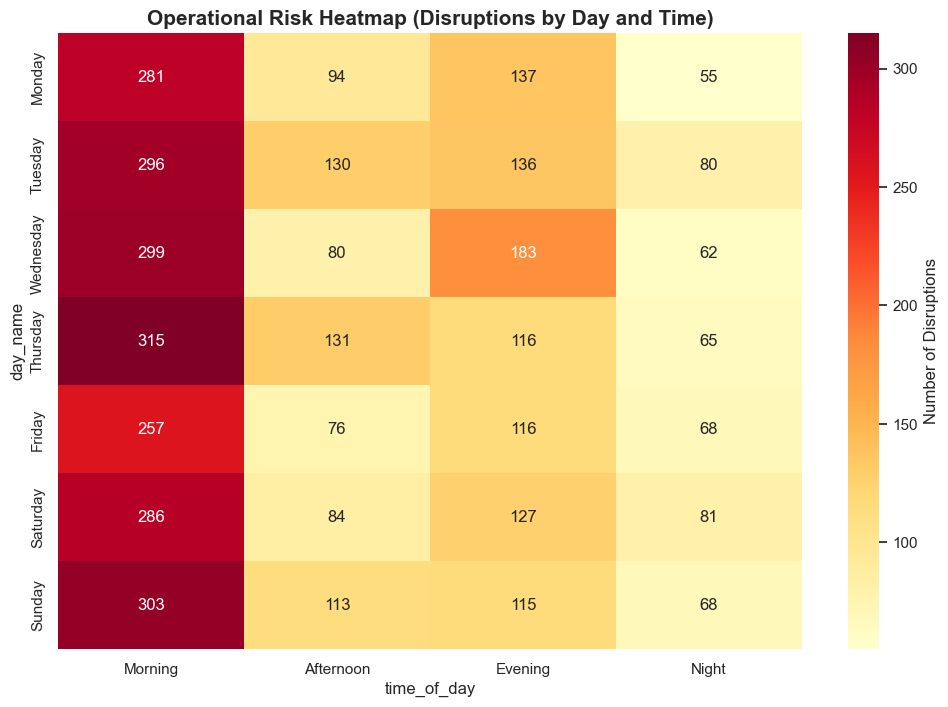

In [132]:
# ==========================================
# Q13: Heatmap: Operational Disruptions (Day vs. Time)
# ==========================================

# حساب عدد الأعطال (تأخير أو إلغاء) لكل توليفة من يوم وفترة زمنية
heatmap_data = df[df['journey_status'] != 'On Time'].pivot_table(
    index='day_name', 
    columns='time_of_day', 
    values='transaction_id', 
    aggfunc='count'
).reindex(index=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
          columns=['Morning', 'Afternoon', 'Evening', 'Night'])

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Number of Disruptions'})

plt.title('Operational Risk Heatmap (Disruptions by Day and Time)', fontsize=15, fontweight='bold')
plt.show()